# DeepCSAT: E-Commerce Customer Satisfaction Score Prediction

Project Type - Multiclass Classification / Deep Learning  
Contribution - Individual  
Team Member 1 - YOUR NAME

# Project Summary

This project aims to develop an Artificial Neural Network model for predicting
customer satisfaction scores from e-commerce customer-support interactions.
The final project summary will be completed after data analysis, model training,
evaluation, and business insight generation.

# GitHub Repository Link

The GitHub repository link will be added after completing the project.

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


### Import Libraries

The required libraries are imported for data manipulation, visualization,
statistical analysis, preprocessing, model development, and evaluation.
Random seeds are also fixed to improve the reproducibility of the experiment.

In [4]:
# Operating system and file path operations
import os

# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    cohen_kappa_score
)

# Baseline model
from sklearn.linear_model import LogisticRegression

# Deep learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Saving preprocessing objects
import joblib

# General settings
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
TensorFlow version: 2.20.0


In [5]:
import os

In [6]:
# Fixed seed helps produce reasonably consistent results across repeated runs.
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print("Random seed set to:", RANDOM_STATE)

Random seed set to: 42


### Dataset Loading

The customer-support dataset is loaded from Google Drive into a Pandas
DataFrame. Exception handling is used to provide a clear message if the file
path is incorrect or the dataset cannot be read.

In [7]:
DATA_PATH = (
    "/content/drive/MyDrive/"
    "DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/"
    "data/eCommerce_Customer_support_data.csv"
)

print("Dataset exists:", os.path.exists(DATA_PATH))
print("Dataset path:", DATA_PATH)

Dataset exists: True
Dataset path: /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/data/eCommerce_Customer_support_data.csv


In [8]:
try:
    df = pd.read_csv(DATA_PATH)

    print("Dataset loaded successfully.")
    print(f"Number of rows: {df.shape[0]:,}")
    print(f"Number of columns: {df.shape[1]}")

except FileNotFoundError:
    print("Dataset file was not found.")
    print("Please verify the DATA_PATH and Google Drive folder structure.")

except Exception as error:
    print("An error occurred while loading the dataset:")
    print(error)

Dataset loaded successfully.
Number of rows: 85,907
Number of columns: 20


### Dataset First View

The first five records are displayed to understand the dataset's structure,
column values, and the type of information available for each customer-support
interaction.

In [9]:
df.head()

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Random Sample of Records

A random sample is examined because the first few rows may not represent the
different types of records present throughout the complete dataset.

In [10]:
df.sample(5, random_state=RANDOM_STATE)

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
67871,fc42f862-7521-472c-b569-8bce866ebe8c,Inbound,Returns,Fraudulent User,NaN,111a13cc-161e-4605-bf68-4e85d2e780c8,NaN,26/08/2023 18:39,26/08/2023 18:48,26-Aug-23,NaN,NaN,NaN,NaN,Brittney Key,Mia Yamamoto,Jennifer Nguyen,On Job Training,Morning,5
40187,a7bb8900-a120-430f-b573-55ed6c16faab,Inbound,Returns,Reverse Pickup Enquiry,Retain employees like this guy. Short and simp...,cbe87ffe-fb02-4f58-97a0-b4f9868d8d6a,09/08/2023 11:15,14/08/2023 00:32,14/08/2023 00:37,14-Aug-23,MUMBAI,Books & General merchandise,156.0,NaN,Jacqueline Meadows,Ethan Nakamura,Emily Chen,0-30,Evening,5
60075,b697f809-0d10-4839-9ccd-152ab6a179f4,Outcall,Returns,Reverse Pickup Enquiry,NaN,3fe3922c-8eac-4274-b1d4-2e10ce94570c,NaN,22/08/2023 20:48,23/08/2023 15:54,23-Aug-23,NaN,NaN,NaN,NaN,Craig Henderson,Brayden Wong,John Smith,>90,Evening,5
69560,8952de8c-48fc-4c9b-b65e-bda8c531e2d5,Inbound,Payments related,Online Payment Issues,Trusted 100/,4bf4fd66-49dc-4a90-8b58-3cd64c9a3aaf,NaN,26/08/2023 23:47,26/08/2023 23:55,26-Aug-23,NaN,NaN,NaN,NaN,Samantha Swanson,Ava Wong,William Kim,On Job Training,Evening,5
2605,fc1c67bc-cb0d-444e-a6da-e5fa6392083b,Inbound,Returns,Reverse Pickup Enquiry,NaN,4e97c673-9132-48cd-a5f4-07b1e292377f,27/07/2023 21:36,01/08/2023 18:37,01/08/2023 18:38,01-Aug-23,PATNA,LifeStyle,294.0,NaN,Stephen Morris,Wyatt Kim,Michael Lee,>90,Evening,5


### Dataset Rows and Columns Count

The dimensions of the dataset are checked to determine the number of
customer-support interactions and the number of available variables.

In [11]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 85,907
Number of columns: 20


### Dataset Column Names

The original column names are inspected before making any changes. This helps
identify inconsistent capitalization, spaces, and naming conventions that
should be standardized during data cleaning.

In [12]:
print("Dataset columns:\n")

for column_number, column_name in enumerate(df.columns, start=1):
    print(f"{column_number}. {column_name}")

Dataset columns:

1. Unique id
2. channel_name
3. category
4. Sub-category
5. Customer Remarks
6. Order_id
7. order_date_time
8. Issue_reported at
9. issue_responded
10. Survey_response_Date
11. Customer_City
12. Product_category
13. Item_price
14. connected_handling_time
15. Agent_name
16. Supervisor
17. Manager
18. Tenure Bucket
19. Agent Shift
20. CSAT Score


### Dataset Information

The dataset information is examined to understand the number of non-null values,
data types, and memory usage of each variable.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

### Statistical Summary of Numerical Variables

Descriptive statistics are generated for numerical variables to examine their
central tendency, spread, minimum values, maximum values, and possible data
quality issues.

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Item_price,17206.0,5660.774846,12825.728411,0.0,392.0,979.0,2699.75,164999.0
connected_handling_time,242.0,462.400826,246.295037,0.0,293.0,427.0,592.25,1986.0
CSAT Score,85907.0,4.242157,1.378903,1.0,4.0,5.0,5.00,5.0


### Statistical Summary of Categorical Variables

Categorical variables are summarized to identify their unique values, most
frequent categories, and category frequencies.

In [16]:
df.describe(include="object").T

,count,unique,top,freq
Unique id,85907,85907,07c7a878-0d5a-42e0-97ef-de59abec0238,1
channel_name,85907,3,Inbound,68142
category,85907,12,Returns,44097
Sub-category,85907,57,Reverse Pickup Enquiry,22389
Customer Remarks,28742,18231,Good,1390
Order_id,67675,67675,3230db30-f8da-4c44-8636-ec76d1d3d4f3,1
order_date_time,17214,13766,09/08/2023 11:55,7
Issue_reported at,85907,30923,13/08/2023 10:40,13
issue_responded,85907,30262,28/08/2023 00:00,3378
Survey_response_Date,85907,31,28-Aug-23,3452


### Duplicate Values

Exact duplicate records are checked because repeated rows can bias the
exploratory analysis and model training. Duplicate identifiers are examined
separately because an identifier should normally be unique.

In [17]:
duplicate_rows = df.duplicated().sum()
duplicate_ids = df["Unique id"].duplicated().sum()

print(f"Exact duplicate rows: {duplicate_rows:,}")
print(f"Duplicate Unique id values: {duplicate_ids:,}")

Exact duplicate rows: 0
Duplicate Unique id values: 0


### Missing Values

Missing values are measured using both counts and percentages. Percentages are
especially useful because they show whether a variable contains enough
information to remain useful for model development.

In [18]:
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_values

,Missing Count,Missing Percentage
connected_handling_time,85665,99.72
Customer_City,68828,80.12
Product_category,68711,79.98
Item_price,68701,79.97
order_date_time,68693,79.96
Customer Remarks,57165,66.54
Order_id,18232,21.22
Unique id,0,0.00
Sub-category,0,0.00
category,0,0.00


### Target Variable Validation

The CSAT Score is the target variable. Its unique values are checked to confirm
that the target contains only the expected satisfaction scores from 1 to 5.

In [19]:
print("Unique CSAT scores:")
print(sorted(df["CSAT Score"].unique()))

print("\nCSAT score frequency:")
print(df["CSAT Score"].value_counts().sort_index())

Unique CSAT scores:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

CSAT score frequency:
CSAT Score
1    11230
2     1283
3     2558
4    11219
5    59617
Name: count, dtype: int64


### CSAT Score Distribution

The frequency and percentage distribution of the target variable are examined
to determine whether the five satisfaction classes are balanced.

In [20]:
csat_distribution = pd.DataFrame({
    "Count": df["CSAT Score"].value_counts().sort_index(),
    "Percentage": (
        df["CSAT Score"].value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

csat_distribution.index.name = "CSAT Score"
csat_distribution

,Count,Percentage
CSAT Score,,
1,11230,13.07
2,1283,1.49
3,2558,2.98
4,11219,13.06
5,59617,69.40


### What Did We Learn About the Dataset?

The dataset contains 85,907 customer-support interactions and 20 variables.
The target variable, CSAT Score, contains five valid classes ranging from 1 to
5, with no missing target values. No exact duplicate records or duplicate
unique identifiers were identified.

The dataset contains substantial missing information in several variables.
Connected handling time is almost entirely missing, while customer city,
product category, item price, and order date are missing for approximately
80% of the records. Customer remarks are missing for more than half of the
observations.

The target distribution is highly imbalanced. CSAT score 5 represents the
majority of the observations, while scores 2 and 3 are relatively rare.
Therefore, accuracy alone would not provide a reliable evaluation of model
performance. Class-sensitive evaluation metrics and appropriate imbalance
handling techniques will be considered during model development.

## 2. Understanding Your Variables

This section examines the meaning, data type, number of unique values, and
sample values of each variable. It helps distinguish identifiers, numerical
features, categorical features, timestamps, text fields, and the target
variable before data cleaning and feature engineering.

In [21]:
variable_overview = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique(dropna=True),
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2),
    "Example Value": [
        df[column].dropna().iloc[0]
        if not df[column].dropna().empty
        else np.nan
        for column in df.columns
    ]
})

variable_overview

,Data Type,Unique Values,Missing Count,Missing Percentage,Example Value
Unique id,object,85907,0,0.00,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f
channel_name,object,3,0,0.00,Outcall
category,object,12,0,0.00,Product Queries
Sub-category,object,57,0,0.00,Life Insurance
Customer Remarks,object,18231,57165,66.54,Very good
Order_id,object,67675,18232,21.22,c27c9bb4-fa36-4140-9f1f-21009254ffdb
order_date_time,object,13766,68693,79.96,19/07/2023 23:50
Issue_reported at,object,30923,0,0.00,01/08/2023 11:13
issue_responded,object,30262,0,0.00,01/08/2023 11:47
Survey_response_Date,object,31,0,0.00,01-Aug-23


### Number of Unique Values

The number of distinct values in each variable is examined to identify
low-cardinality categories, high-cardinality categories, and identifier-like
features.

In [22]:
unique_value_summary = (
    df.nunique(dropna=True)
    .sort_values(ascending=True)
    .rename("Unique Values")
    .to_frame()
)

unique_value_summary

,Unique Values
channel_name,3
CSAT Score,5
Agent Shift,5
Tenure Bucket,5
Manager,6
Product_category,9
category,12
Survey_response_Date,31
Supervisor,40
Sub-category,57


### Unique Categories in Low-Cardinality Variables

The values of categorical variables with a manageable number of categories
are displayed to check category labels, spelling consistency, and possible
data-entry variations.

In [23]:
low_cardinality_columns = [
    column
    for column in df.columns
    if df[column].nunique(dropna=True) <= 15
]

for column in low_cardinality_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(df[column].dropna().unique())


channel_name
------------
['Outcall' 'Inbound' 'Email']

category
--------
['Product Queries' 'Order Related' 'Returns' 'Cancellation'
 'Shopzilla Related' 'Payments related' 'Refund Related' 'Feedback'
 'Offers & Cashback' 'Onboarding related' 'Others' 'App/website']

Product_category
----------------
['LifeStyle' 'Electronics' 'Mobile' 'Home Appliences' 'Furniture' 'Home'
 'Books & General merchandise' 'GiftCard' 'Affiliates']

Manager
-------
['Jennifer Nguyen' 'Michael Lee' 'William Kim' 'John Smith' 'Olivia Tan'
 'Emily Chen']

Tenure Bucket
-------------
['On Job Training' '>90' '0-30' '31-60' '61-90']

Agent Shift
-----------
['Morning' 'Evening' 'Split' 'Afternoon' 'Night']

CSAT Score
----------
[5 4 1 3 2]


### High-Cardinality Variables

Variables containing many distinct values are identified because one-hot
encoding them directly can create an unnecessarily large model input space.

In [24]:
high_cardinality_summary = pd.DataFrame({
    "Unique Values": df.nunique(dropna=True),
    "Unique Percentage": (
        df.nunique(dropna=True) / len(df) * 100
    ).round(2)
})

high_cardinality_summary = high_cardinality_summary[
    high_cardinality_summary["Unique Values"] > 50
].sort_values(by="Unique Values", ascending=False)

high_cardinality_summary

,Unique Values,Unique Percentage
Unique id,85907,100.00
Order_id,67675,78.78
Issue_reported at,30923,36.00
issue_responded,30262,35.23
Customer Remarks,18231,21.22
order_date_time,13766,16.02
Item_price,2789,3.25
Customer_City,1782,2.07
Agent_name,1371,1.60
connected_handling_time,211,0.25


### Inspection of Date and Time Variables

Sample values from the date and time variables are inspected before conversion.
This confirms their source formats and helps prevent incorrect day-month
interpretation during timestamp parsing.

In [25]:
date_columns = [
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date"
]

for column in date_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(df[column].dropna().head(5).tolist())


order_date_time
---------------
['19/07/2023 23:50', '06/05/2023 21:41', '18/07/2023 12:20', '15/07/2023 14:47', '29/07/2023 13:35']

Issue_reported at
-----------------
['01/08/2023 11:13', '01/08/2023 12:52', '01/08/2023 20:16', '01/08/2023 20:56', '01/08/2023 10:30']

issue_responded
---------------
['01/08/2023 11:47', '01/08/2023 12:54', '01/08/2023 20:38', '01/08/2023 21:16', '01/08/2023 10:32']

Survey_response_Date
--------------------
['01-Aug-23', '01-Aug-23', '01-Aug-23', '01-Aug-23', '01-Aug-23']


### Classification of Variables by Their Role

The dataset variables are grouped according to their analytical role.
Different variable types require different preprocessing methods before they
can be provided to an Artificial Neural Network.

In [26]:
identifier_columns = [
    "Unique id",
    "Order_id"
]

date_columns = [
    "order_date_time",
    "Issue_reported at",
    "issue_responded",
    "Survey_response_Date"
]

numeric_columns = [
    "Item_price",
    "connected_handling_time"
]

text_columns = [
    "Customer Remarks"
]

categorical_columns = [
    "channel_name",
    "category",
    "Sub-category",
    "Customer_City",
    "Product_category",
    "Agent_name",
    "Supervisor",
    "Manager",
    "Tenure Bucket",
    "Agent Shift"
]

target_column = "CSAT Score"

print("Identifier columns:", identifier_columns)
print("Date columns:", date_columns)
print("Numerical columns:", numeric_columns)
print("Text columns:", text_columns)
print("Categorical columns:", categorical_columns)
print("Target column:", target_column)

Identifier columns: ['Unique id', 'Order_id']
Date columns: ['order_date_time', 'Issue_reported at', 'issue_responded', 'Survey_response_Date']
Numerical columns: ['Item_price', 'connected_handling_time']
Text columns: ['Customer Remarks']
Categorical columns: ['channel_name', 'category', 'Sub-category', 'Customer_City', 'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']
Target column: CSAT Score


### Identifier Validation

The Unique id variable is validated to confirm that every customer-support
interaction has a non-missing and distinct identifier. The identifier is useful
for record tracking but will not be used as a predictive model input.

In [27]:
total_records = len(df)
unique_ids = df["Unique id"].nunique(dropna=True)
missing_ids = df["Unique id"].isnull().sum()
duplicate_ids = df["Unique id"].duplicated().sum()

print(f"Total records: {total_records:,}")
print(f"Unique ID values: {unique_ids:,}")
print(f"Missing Unique ID values: {missing_ids:,}")
print(f"Duplicate Unique ID values: {duplicate_ids:,}")

if (
    total_records == unique_ids
    and missing_ids == 0
    and duplicate_ids == 0
):
    print("Unique id validation: PASSED")
else:
    print("Unique id validation: REVIEW REQUIRED")

Total records: 85,907
Unique ID values: 85,907
Missing Unique ID values: 0
Duplicate Unique ID values: 0
Unique id validation: PASSED


### Initial Feature Inclusion and Exclusion Decisions

An initial feature-usage plan is created based on the prediction timing. The
intended use case is to predict customer satisfaction after the support response
but before the customer submits the satisfaction survey.

In [28]:
feature_decisions = pd.DataFrame({
    "Variable": [
        "Unique id",
        "Order_id",
        "Survey_response_Date",
        "Issue_reported at",
        "issue_responded",
        "Customer Remarks"
    ],
    "Initial Decision": [
        "Exclude from model",
        "Exclude raw value",
        "Exclude from model",
        "Use for feature engineering",
        "Use for feature engineering",
        "Review before inclusion"
    ],
    "Reason": [
        "Record identifier with no predictive business meaning",
        "High-cardinality identifier; may encourage memorization",
        "Generated after the interaction and may cause data leakage",
        "Used to derive reporting hour, weekday, and response delay",
        "Used with issue time to calculate response delay",
        "Timing and availability must be confirmed before model use"
    ]
})

feature_decisions

,Variable,Initial Decision,Reason
0,Unique id,Exclude from model,Record identifier with no predictive business ...
1,Order_id,Exclude raw value,High-cardinality identifier; may encourage mem...
2,Survey_response_Date,Exclude from model,Generated after the interaction and may cause ...
3,Issue_reported at,Use for feature engineering,"Used to derive reporting hour, weekday, and re..."
4,issue_responded,Use for feature engineering,Used with issue time to calculate response delay
5,Customer Remarks,Review before inclusion,Timing and availability must be confirmed befo...


## 3. Data Wrangling

### Creating a Working Copy and Standardizing Column Names

A separate working copy of the original dataset is created before cleaning.
Column names are standardized to lowercase snake_case so that they remain
consistent, readable, and less prone to typing errors throughout the project.

In [29]:
# Preserve the original dataset and perform cleaning on a separate copy.
df_clean = df.copy()

# Standardize column names.
df_clean.columns = (
    df_clean.columns
    .str.strip()
    .str.lower()
    .str.replace("-", "_", regex=False)
    .str.replace(" ", "_", regex=False)
    .str.replace(r"_+", "_", regex=True)
)

print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

print("\nStandardized column names:")
for number, column in enumerate(df_clean.columns, start=1):
    print(f"{number}. {column}")

Original dataset shape: (85907, 20)
Working dataset shape: (85907, 20)

Standardized column names:
1. unique_id
2. channel_name
3. category
4. sub_category
5. customer_remarks
6. order_id
7. order_date_time
8. issue_reported_at
9. issue_responded
10. survey_response_date
11. customer_city
12. product_category
13. item_price
14. connected_handling_time
15. agent_name
16. supervisor
17. manager
18. tenure_bucket
19. agent_shift
20. csat_score


### Cleaning Text and Categorical Values

Leading spaces, trailing spaces, and repeated internal spaces are removed from
text-based variables. Empty strings are converted into missing values so that
they can be handled consistently during preprocessing.

In [30]:
text_based_columns = [
    "channel_name",
    "category",
    "sub_category",
    "customer_remarks",
    "customer_city",
    "product_category",
    "agent_name",
    "supervisor",
    "manager",
    "tenure_bucket",
    "agent_shift"
]

for column in text_based_columns:
    df_clean[column] = (
        df_clean[column]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
        .replace("", pd.NA)
    )

# Verify that leading and trailing spaces have been removed.
whitespace_check = {
    column: (
        df_clean[column].dropna()
        == df_clean[column].dropna().str.strip()
    ).all()
    for column in text_based_columns
}

print("Text cleaning completed.")
print("All text columns passed the whitespace check:",
      all(whitespace_check.values()))
print("Dataset shape after text cleaning:", df_clean.shape)

Text cleaning completed.
All text columns passed the whitespace check: True
Dataset shape after text cleaning: (85907, 20)


### Parsing Date and Time Variables

Date and time variables are converted from text into proper datetime values
using their observed source formats. Parsing failures are measured separately
to ensure that invalid timestamps are not silently introduced.

In [31]:
date_formats = {
    "order_date_time": "%d/%m/%Y %H:%M",
    "issue_reported_at": "%d/%m/%Y %H:%M",
    "issue_responded": "%d/%m/%Y %H:%M",
    "survey_response_date": "%d-%b-%y"
}

date_parsing_report = []

for column, date_format in date_formats.items():
    original_non_null = df_clean[column].notna()

    converted_values = pd.to_datetime(
        df_clean[column],
        format=date_format,
        errors="coerce"
    )

    parsing_failures = (
        original_non_null & converted_values.isna()
    ).sum()

    df_clean[column] = converted_values

    date_parsing_report.append({
        "Column": column,
        "Converted Data Type": str(df_clean[column].dtype),
        "Original Non-Null Values": int(original_non_null.sum()),
        "Parsing Failures": int(parsing_failures)
    })

date_parsing_report = pd.DataFrame(date_parsing_report)

date_parsing_report

,Column,Converted Data Type,Original Non-Null Values,Parsing Failures
0,order_date_time,datetime64[ns],17214,0
1,issue_reported_at,datetime64[ns],85907,0
2,issue_responded,datetime64[ns],85907,0
3,survey_response_date,datetime64[ns],85907,0


### Numerical Data Validation

Numerical variables are converted explicitly into numeric format and checked
for missing, negative, zero, and invalid values. This prevents invalid values
from silently affecting feature engineering and model training.

In [32]:
numeric_conversion_columns = [
    "item_price",
    "connected_handling_time",
    "csat_score"
]

for column in numeric_conversion_columns:
    df_clean[column] = pd.to_numeric(
        df_clean[column],
        errors="coerce"
    )

numerical_validation = pd.DataFrame({
    "Missing Values": [
        df_clean["item_price"].isna().sum(),
        df_clean["connected_handling_time"].isna().sum(),
        df_clean["csat_score"].isna().sum()
    ],
    "Negative Values": [
        (df_clean["item_price"] < 0).sum(),
        (df_clean["connected_handling_time"] < 0).sum(),
        (df_clean["csat_score"] < 0).sum()
    ],
    "Zero Values": [
        (df_clean["item_price"] == 0).sum(),
        (df_clean["connected_handling_time"] == 0).sum(),
        (df_clean["csat_score"] == 0).sum()
    ]
}, index=[
    "item_price",
    "connected_handling_time",
    "csat_score"
])

invalid_csat_scores = (
    ~df_clean["csat_score"].isin([1, 2, 3, 4, 5])
).sum()

display(numerical_validation)
print("Invalid CSAT scores:", invalid_csat_scores)

,Missing Values,Negative Values,Zero Values
item_price,68701,0,1
connected_handling_time,85665,0,2
csat_score,0,0,0


Invalid CSAT scores: 0


### Creating Time-Duration Features

Response time and order-to-issue duration are derived from the cleaned
timestamps. Duration features provide more useful operational information than
the original timestamps alone.

In [33]:
# Time taken by the support team to respond to the reported issue.
df_clean["response_time_minutes"] = (
    df_clean["issue_responded"]
    - df_clean["issue_reported_at"]
).dt.total_seconds() / 60

# Time between placing the order and reporting the issue.
df_clean["order_to_issue_hours"] = (
    df_clean["issue_reported_at"]
    - df_clean["order_date_time"]
).dt.total_seconds() / 3600

duration_validation = pd.DataFrame({
    "Non-Missing Values": [
        df_clean["response_time_minutes"].notna().sum(),
        df_clean["order_to_issue_hours"].notna().sum()
    ],
    "Missing Values": [
        df_clean["response_time_minutes"].isna().sum(),
        df_clean["order_to_issue_hours"].isna().sum()
    ],
    "Negative Values": [
        (df_clean["response_time_minutes"] < 0).sum(),
        (df_clean["order_to_issue_hours"] < 0).sum()
    ],
    "Median": [
        df_clean["response_time_minutes"].median(),
        df_clean["order_to_issue_hours"].median()
    ]
}, index=[
    "response_time_minutes",
    "order_to_issue_hours"
])

duration_validation

,Non-Missing Values,Missing Values,Negative Values,Median
response_time_minutes,85907,0,3128,5.00
order_to_issue_hours,17214,68693,58,216.95


### Handling Invalid Duration Values

Negative duration values are treated as data-quality errors and replaced with
missing values. Separate indicator variables preserve the information that an
invalid timestamp combination was present in the original record.

In [34]:
# Create indicators before replacing invalid values.
df_clean["invalid_response_time"] = (
    df_clean["response_time_minutes"] < 0
).astype(int)

df_clean["invalid_order_to_issue_time"] = (
    df_clean["order_to_issue_hours"] < 0
).astype(int)

# Replace logically invalid negative durations with missing values.
df_clean.loc[
    df_clean["response_time_minutes"] < 0,
    "response_time_minutes"
] = np.nan

df_clean.loc[
    df_clean["order_to_issue_hours"] < 0,
    "order_to_issue_hours"
] = np.nan

print(
    "Invalid response-time records identified:",
    df_clean["invalid_response_time"].sum()
)

print(
    "Invalid order-to-issue records identified:",
    df_clean["invalid_order_to_issue_time"].sum()
)

print(
    "Negative response times remaining:",
    (df_clean["response_time_minutes"] < 0).sum()
)

print(
    "Negative order-to-issue times remaining:",
    (df_clean["order_to_issue_hours"] < 0).sum()
)

print(
    "Missing response times after cleaning:",
    df_clean["response_time_minutes"].isna().sum()
)

print(
    "Missing order-to-issue values after cleaning:",
    df_clean["order_to_issue_hours"].isna().sum()
)

print("Current dataset shape:", df_clean.shape)

Invalid response-time records identified: 3128
Invalid order-to-issue records identified: 58
Negative response times remaining: 0
Negative order-to-issue times remaining: 0
Missing response times after cleaning: 3128
Missing order-to-issue values after cleaning: 68751
Current dataset shape: (85907, 24)


### Creating Calendar-Based Features

Calendar-based features are extracted from the issue reporting timestamp.
These features allow the model to examine whether customer satisfaction varies
by reporting hour, day of the week, or weekend status.

In [35]:
df_clean["issue_hour"] = (
    df_clean["issue_reported_at"].dt.hour
)

df_clean["issue_day_of_week"] = (
    df_clean["issue_reported_at"].dt.day_name()
)

df_clean["issue_day_number"] = (
    df_clean["issue_reported_at"].dt.dayofweek
)

df_clean["is_weekend"] = (
    df_clean["issue_day_number"].isin([5, 6]).astype(int)
)

# Used for chronological analysis and dataset splitting.
df_clean["issue_date"] = (
    df_clean["issue_reported_at"].dt.date
)

print("Minimum reporting hour:", df_clean["issue_hour"].min())
print("Maximum reporting hour:", df_clean["issue_hour"].max())
print("Missing reporting hours:", df_clean["issue_hour"].isna().sum())

print("\nWeekend distribution:")
print(df_clean["is_weekend"].value_counts().sort_index())

print("\nCurrent dataset shape:", df_clean.shape)

Minimum reporting hour: 0
Maximum reporting hour: 23
Missing reporting hours: 0

Weekend distribution:
is_weekend
0    64335
1    21572
Name: count, dtype: int64

Current dataset shape: (85907, 29)


### Creating Missing-Value Indicators

Missing-value indicator features are created for variables with substantial
missing information. These indicators allow the model to learn whether the
absence of information itself is associated with customer satisfaction.

In [36]:
missing_indicator_columns = [
    "order_id",
    "order_date_time",
    "customer_remarks",
    "customer_city",
    "product_category",
    "item_price",
    "connected_handling_time"
]

for column in missing_indicator_columns:
    indicator_name = f"is_{column}_missing"
    df_clean[indicator_name] = (
        df_clean[column].isna().astype(int)
    )

missing_indicator_summary = pd.DataFrame({
    "Original Variable": missing_indicator_columns,
    "Missing Records": [
        int(df_clean[column].isna().sum())
        for column in missing_indicator_columns
    ],
    "Indicator Variable": [
        f"is_{column}_missing"
        for column in missing_indicator_columns
    ]
})

display(missing_indicator_summary)
print("Current dataset shape:", df_clean.shape)

,Original Variable,Missing Records,Indicator Variable
0,order_id,18232,is_order_id_missing
1,order_date_time,68693,is_order_date_time_missing
2,customer_remarks,57165,is_customer_remarks_missing
3,customer_city,68828,is_customer_city_missing
4,product_category,68711,is_product_category_missing
5,item_price,68701,is_item_price_missing
6,connected_handling_time,85665,is_connected_handling_time_missing


Current dataset shape: (85907, 36)


### Defining the Initial Modeling Exclusion List

Variables that contain identifiers, post-outcome information, raw timestamps,
or insufficient usable data are marked for exclusion from the primary
structured-data ANN model. The columns remain available in the cleaned dataset
for auditing and exploratory analysis.

In [37]:
model_excluded_columns = [
    "unique_id",
    "order_id",
    "survey_response_date",
    "issue_reported_at",
    "issue_responded",
    "order_date_time",
    "issue_date",
    "connected_handling_time",
    "customer_remarks"
]

exclusion_reasons = [
    "Record identifier with no predictive business meaning",
    "High-cardinality order identifier",
    "Post-interaction survey information and possible leakage",
    "Raw timestamp replaced by engineered time features",
    "Raw timestamp replaced by response-time feature",
    "Raw timestamp replaced by order-to-issue duration",
    "Used for chronological splitting, not as a model input",
    "Approximately 99.72% values are missing",
    "Excluded from primary structured ANN; optional NLP experiment"
]

model_exclusion_plan = pd.DataFrame({
    "Excluded Variable": model_excluded_columns,
    "Reason": exclusion_reasons
})

model_exclusion_plan

,Excluded Variable,Reason
0,unique_id,Record identifier with no predictive business ...
1,order_id,High-cardinality order identifier
2,survey_response_date,Post-interaction survey information and possib...
3,issue_reported_at,Raw timestamp replaced by engineered time feat...
4,issue_responded,Raw timestamp replaced by response-time feature
5,order_date_time,Raw timestamp replaced by order-to-issue duration
6,issue_date,"Used for chronological splitting, not as a mod..."
7,connected_handling_time,Approximately 99.72% values are missing
8,customer_remarks,Excluded from primary structured ANN; optional...


### Duplicate Validation After Cleaning

Duplicate records are checked again after standardizing text and converting
timestamps. This ensures that formatting differences were not hiding duplicate
customer-support interactions in the original dataset.

In [38]:
duplicate_rows_after_cleaning = df_clean.duplicated().sum()
duplicate_ids_after_cleaning = (
    df_clean["unique_id"].duplicated().sum()
)

print(
    "Exact duplicate rows after cleaning:",
    duplicate_rows_after_cleaning
)

print(
    "Duplicate unique IDs after cleaning:",
    duplicate_ids_after_cleaning
)

print(
    "Dataset shape:",
    df_clean.shape
)

Exact duplicate rows after cleaning: 0
Duplicate unique IDs after cleaning: 0
Dataset shape: (85907, 36)


### Numerical Distribution and Outlier Assessment

The distributions of the main numerical variables are examined using
percentiles and skewness. This helps determine whether transformation is
required before providing these variables to the neural network.

In [39]:
numerical_features_to_assess = [
    "item_price",
    "response_time_minutes",
    "order_to_issue_hours"
]

numerical_distribution = df_clean[
    numerical_features_to_assess
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.95, 0.99]
).T

numerical_distribution["skewness"] = (
    df_clean[numerical_features_to_assess].skew()
)

numerical_distribution = numerical_distribution[
    [
        "count",
        "min",
        "25%",
        "50%",
        "75%",
        "95%",
        "99%",
        "max",
        "skewness"
    ]
].round(2)

numerical_distribution

,count,min,25%,50%,75%,95%,99%,max,skewness
item_price,17206.0,0.00,392.00,979.00,2699.75,31999.00,62998.55,164999.0,4.23
response_time_minutes,82779.0,0.00,2.00,6.00,39.00,1124.00,3047.22,5758.0,5.22
order_to_issue_hours,17156.0,0.12,136.02,217.45,370.00,1079.54,6163.92,13954.8,6.89


### Log Transformation of Skewed Numerical Features

A log1p transformation is applied to the highly right-skewed numerical
variables. The transformation reduces the influence of extreme values while
retaining all valid observations, including zero values.

In [40]:
log_transform_columns = [
    "item_price",
    "response_time_minutes",
    "order_to_issue_hours"
]

for column in log_transform_columns:
    df_clean[f"log_{column}"] = np.log1p(
        df_clean[column]
    )

skewness_comparison = pd.DataFrame({
    "Original Skewness": [
        df_clean[column].skew()
        for column in log_transform_columns
    ],
    "Log-Transformed Skewness": [
        df_clean[f"log_{column}"].skew()
        for column in log_transform_columns
    ],
    "Available Values": [
        df_clean[f"log_{column}"].notna().sum()
        for column in log_transform_columns
    ]
}, index=log_transform_columns).round(3)

display(skewness_comparison)
print("Current dataset shape:", df_clean.shape)

,Original Skewness,Log-Transformed Skewness,Available Values
item_price,4.228,0.516,17206
response_time_minutes,5.222,1.071,82779
order_to_issue_hours,6.889,0.127,17156


Current dataset shape: (85907, 39)


## 4. Data Visualization, Storytelling and Experimenting with Charts

### Chart 1: Distribution of CSAT Scores

This chart examines the frequency and percentage distribution of the target
variable. Understanding target imbalance is essential before selecting model
evaluation metrics and imbalance-handling techniques.

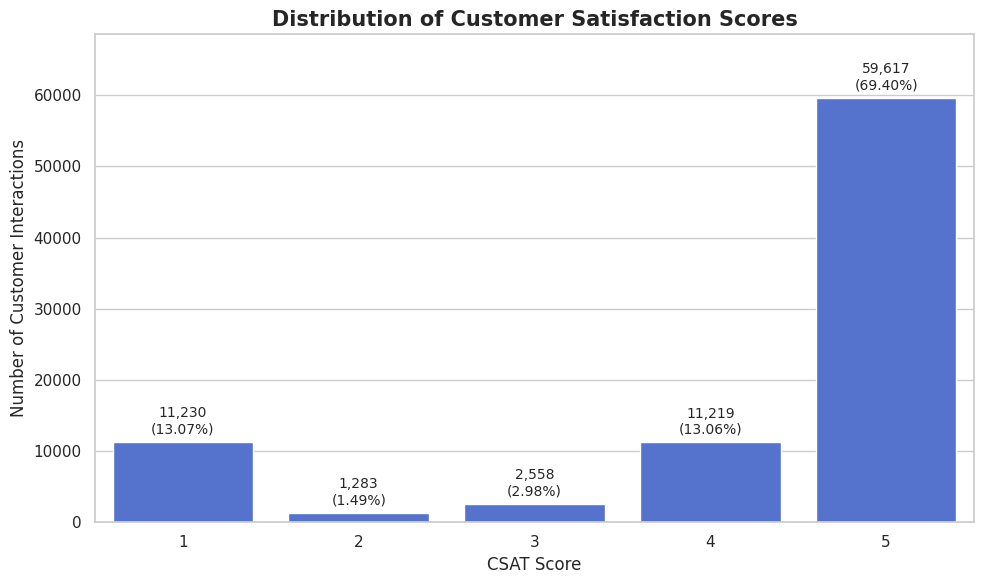

In [41]:
target_counts = (
    df_clean["csat_score"]
    .value_counts()
    .sort_index()
)

target_percentages = (
    target_counts / target_counts.sum() * 100
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    color="#4169E1"
)

for position, (count, percentage) in enumerate(
    zip(target_counts.values, target_percentages.values)
):
    ax.text(
        position,
        count + 800,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Distribution of Customer Satisfaction Scores",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("CSAT Score")
plt.ylabel("Number of Customer Interactions")
plt.ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()

#### 1. Why was this chart selected?

A bar chart is appropriate because CSAT Score is a discrete target variable
with five classes. It allows direct comparison of the number and percentage of
observations in each satisfaction class.

#### 2. What insights were found?

CSAT score 5 accounts for approximately 69.40% of all observations. Scores 2
and 3 are rare, representing approximately 1.49% and 2.98% of the dataset.
Therefore, the target variable is highly imbalanced.

#### 3. What is the potential business impact?

The high proportion of score 5 indicates that most recorded interactions
received excellent satisfaction ratings. However, a model could achieve high
accuracy by primarily predicting score 5 while failing to identify dissatisfied
customers. Macro-F1, class-wise recall, confusion matrix, MAE, and weighted
kappa will therefore be considered alongside accuracy.

### Chart 2: Missing-Value Percentage by Variable

This chart compares the percentage of missing records in the original dataset
variables. It helps identify data-quality limitations and guides column-specific
missing-value treatment.

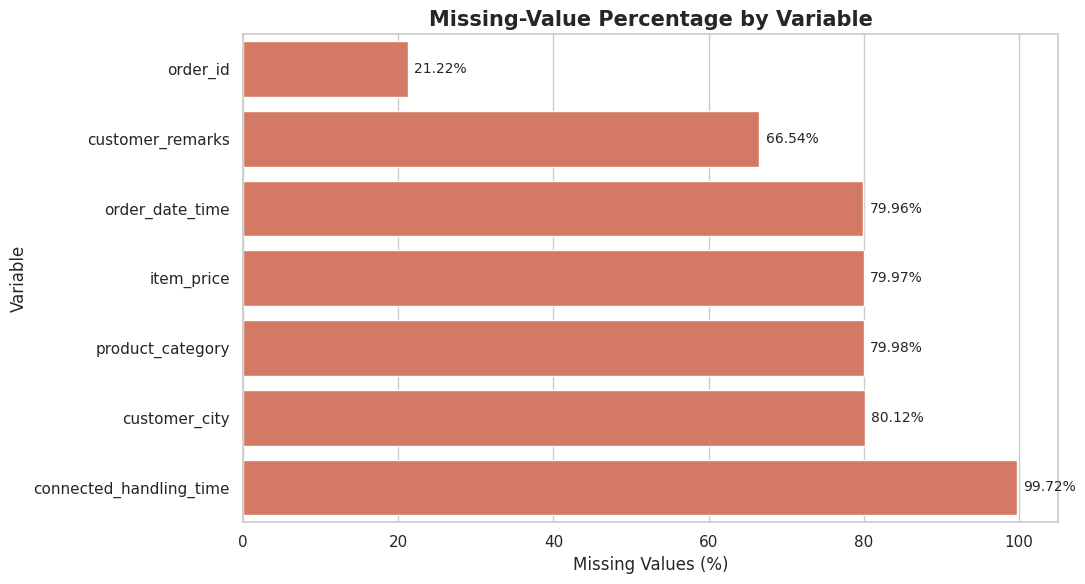

In [42]:
original_clean_columns = [
    "unique_id",
    "channel_name",
    "category",
    "sub_category",
    "customer_remarks",
    "order_id",
    "order_date_time",
    "issue_reported_at",
    "issue_responded",
    "survey_response_date",
    "customer_city",
    "product_category",
    "item_price",
    "connected_handling_time",
    "agent_name",
    "supervisor",
    "manager",
    "tenure_bucket",
    "agent_shift",
    "csat_score"
]

missing_percentage = (
    df_clean[original_clean_columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

missing_percentage = missing_percentage[
    missing_percentage > 0
]

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    x=missing_percentage.values,
    y=missing_percentage.index,
    color="#E76F51"
)

for position, percentage in enumerate(
    missing_percentage.values
):
    ax.text(
        percentage + 0.8,
        position,
        f"{percentage:.2f}%",
        va="center",
        fontsize=10
    )

plt.title(
    "Missing-Value Percentage by Variable",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Missing Values (%)")
plt.ylabel("Variable")
plt.xlim(0, 105)
plt.tight_layout()
plt.show()

#### 1. Why was this chart selected?

A horizontal bar chart makes it easy to compare missing-value percentages and
display variable names clearly. It highlights variables requiring the most
careful treatment.

#### 2. What insights were found?

Connected handling time is missing for approximately 99.72% of records and is
not suitable as a primary numerical model feature. Customer city, product
category, item price, and order date are missing in approximately 80% of the
records. Customer remarks are missing in approximately 66.54% of interactions.

#### 3. What is the potential business impact?

Dropping every record containing a missing value would remove most of the
dataset and could introduce selection bias. Missing indicators and
training-data-based imputation will be used where appropriate. The almost
entirely missing connected handling time variable will be excluded from the
primary ANN model. The high missingness also indicates an opportunity to
improve operational data-collection processes.

### Chart 3: Distribution of Customer-Support Channels

This chart compares interaction volumes across the available customer-support
channels. It helps determine whether the dataset and resulting model are
dominated by a particular service channel.

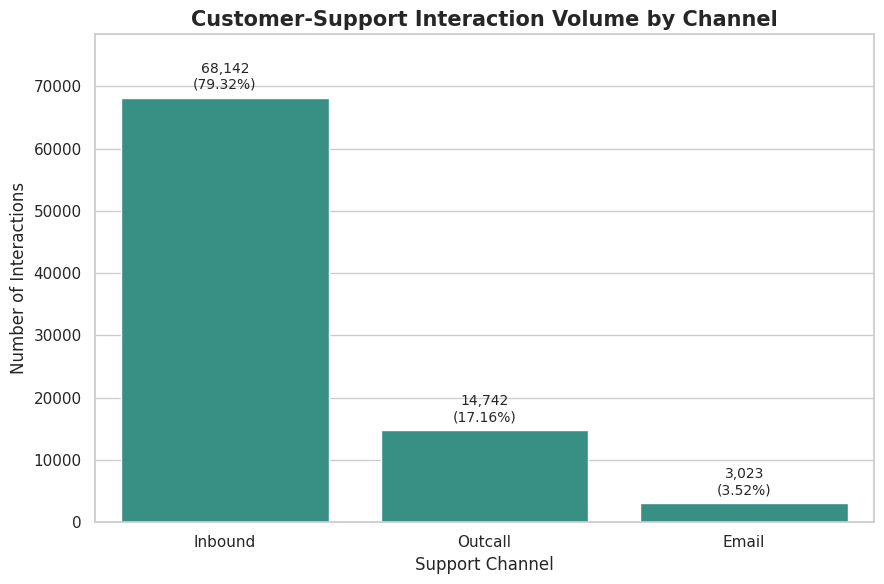

In [43]:
channel_counts = (
    df_clean["channel_name"]
    .value_counts()
)

channel_percentages = (
    channel_counts / channel_counts.sum() * 100
)

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=channel_counts.index,
    y=channel_counts.values,
    color="#2A9D8F"
)

for position, (count, percentage) in enumerate(
    zip(channel_counts.values, channel_percentages.values)
):
    ax.text(
        position,
        count + 1000,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Customer-Support Interaction Volume by Channel",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Support Channel")
plt.ylabel("Number of Interactions")
plt.ylim(0, channel_counts.max() * 1.15)
plt.tight_layout()
plt.show()

#### 1. Why was this chart selected?

A bar chart is suitable because channel name is a categorical variable and the
business needs to compare interaction volumes across a small number of service
channels.

#### 2. What insights were found?

Inbound interactions account for approximately 79.32% of the dataset. Outcall
interactions represent approximately 17.16%, while email contributes only
approximately 3.52%. The dataset is therefore primarily representative of
inbound customer-support activity.

#### 3. What is the potential business impact?

The model may learn inbound interaction patterns more effectively because that
channel has substantially more training data. Performance should be evaluated
separately by channel to ensure that email and outcall interactions are not
overlooked. Operationally, inbound support is the largest area for potential
service improvement because it handles most customer interactions.

### Chart 4: Customer-Support Interaction Volume by Category

This chart compares the volume of customer-support interactions across the
main issue categories. It identifies the business areas generating the highest
support demand.

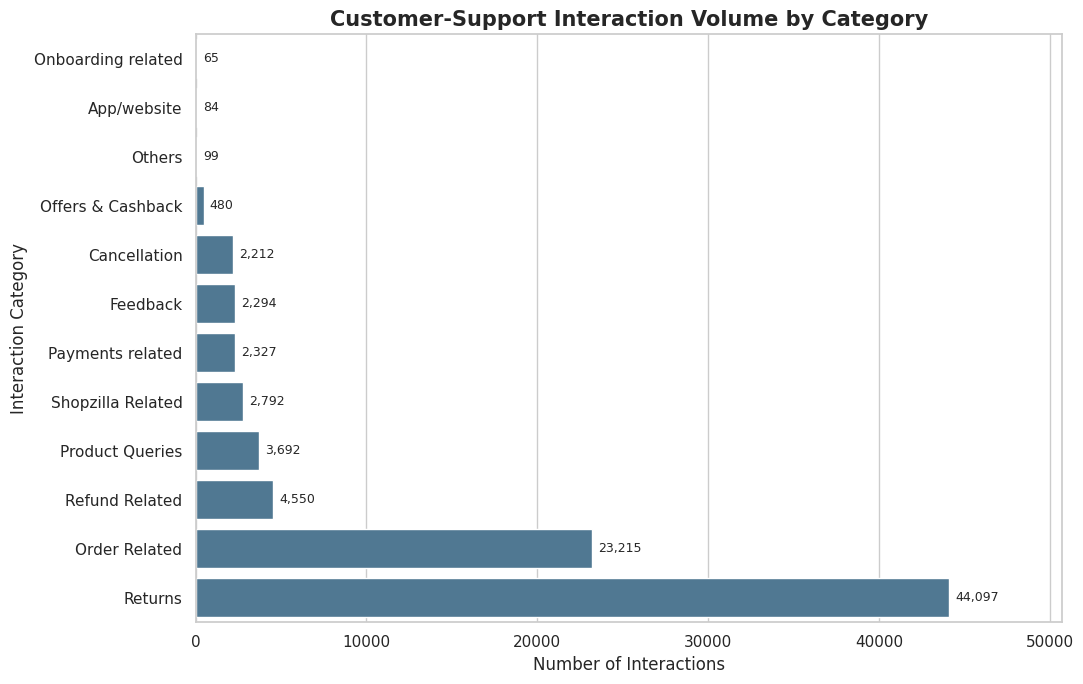

In [44]:
category_counts = (
    df_clean["category"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    color="#457B9D"
)

for position, count in enumerate(category_counts.values):
    ax.text(
        count + 350,
        position,
        f"{count:,}",
        va="center",
        fontsize=9
    )

plt.title(
    "Customer-Support Interaction Volume by Category",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Number of Interactions")
plt.ylabel("Interaction Category")
plt.xlim(0, category_counts.max() * 1.15)
plt.tight_layout()
plt.show()

#### 1. Why was this chart selected?

A horizontal bar chart clearly compares interaction volumes across multiple
categories while keeping the category labels readable.

#### 2. What insights were found?

Returns generated 44,097 interactions and represent more than half of the
dataset. Order-related issues generated 23,215 interactions. Together, these
two categories account for approximately 78% of customer-support demand.

#### 3. What is the potential business impact?

Return and order-related workflows offer the largest opportunity for reducing
support volume and improving customer experience. The business should examine
return instructions, reverse-pickup communication, order tracking, and
self-service options. Categories with very few observations may also produce
less reliable category-specific model predictions.

### Chart 5: Ten Most Frequent Support Sub-Categories

This chart provides a more detailed view of the specific customer issues
responsible for the largest number of support interactions.

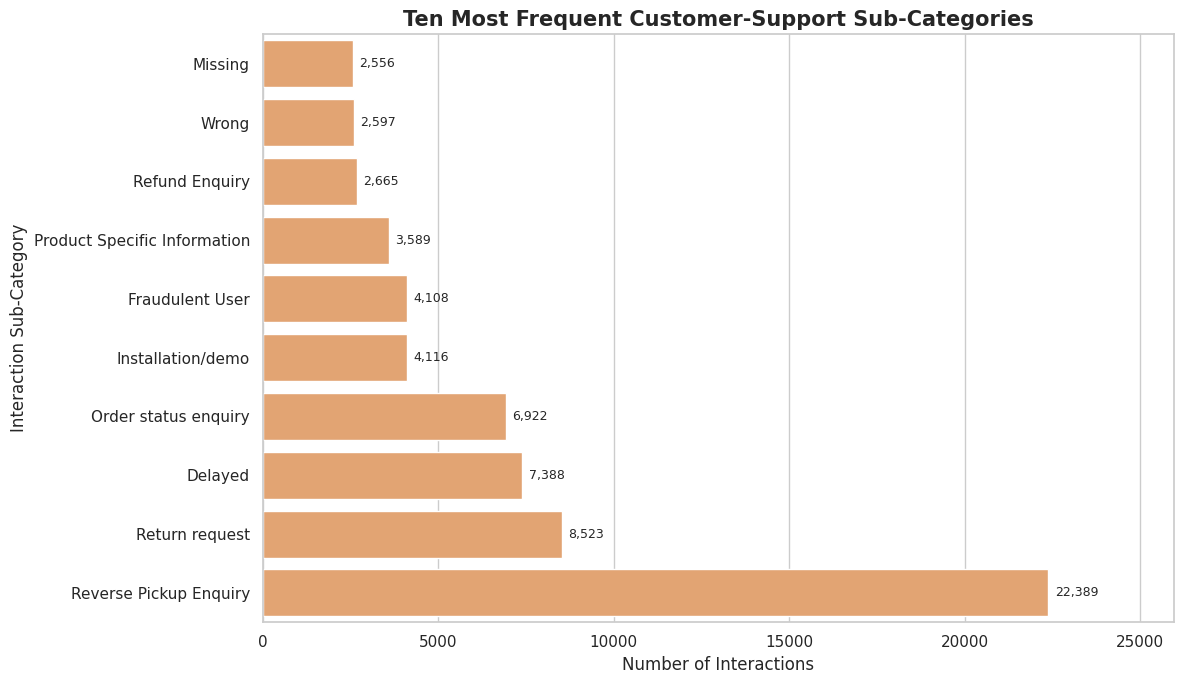

In [45]:
top_subcategory_counts = (
    df_clean["sub_category"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top_subcategory_counts.values,
    y=top_subcategory_counts.index,
    color="#F4A261"
)

for position, count in enumerate(
    top_subcategory_counts.values
):
    ax.text(
        count + 180,
        position,
        f"{count:,}",
        va="center",
        fontsize=9
    )

plt.title(
    "Ten Most Frequent Customer-Support Sub-Categories",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Number of Interactions")
plt.ylabel("Interaction Sub-Category")
plt.xlim(0, top_subcategory_counts.max() * 1.16)
plt.tight_layout()
plt.show()

#### 1. Why was this chart selected?

The main categories combine several different customer problems. A top-ten
horizontal bar chart reveals the specific issues responsible for the greatest
support workload.

#### 2. What insights were found?

Reverse Pickup Enquiry is the most frequent sub-category with 22,389
interactions. Return requests, delayed orders, and order-status enquiries are
also major sources of customer contact.

#### 3. What is the potential business impact?

Clear reverse-pickup status updates and proactive return communication could
reduce a substantial number of support contacts. Better shipment tracking and
delay notifications may also reduce order-status enquiries and improve the
customer experience.

### Chart 6: Percentage Distribution of CSAT Scores by Support Channel

This chart compares the complete CSAT distribution across support channels.
Percentages are used because the number of interactions differs substantially
between inbound, outcall, and email channels.

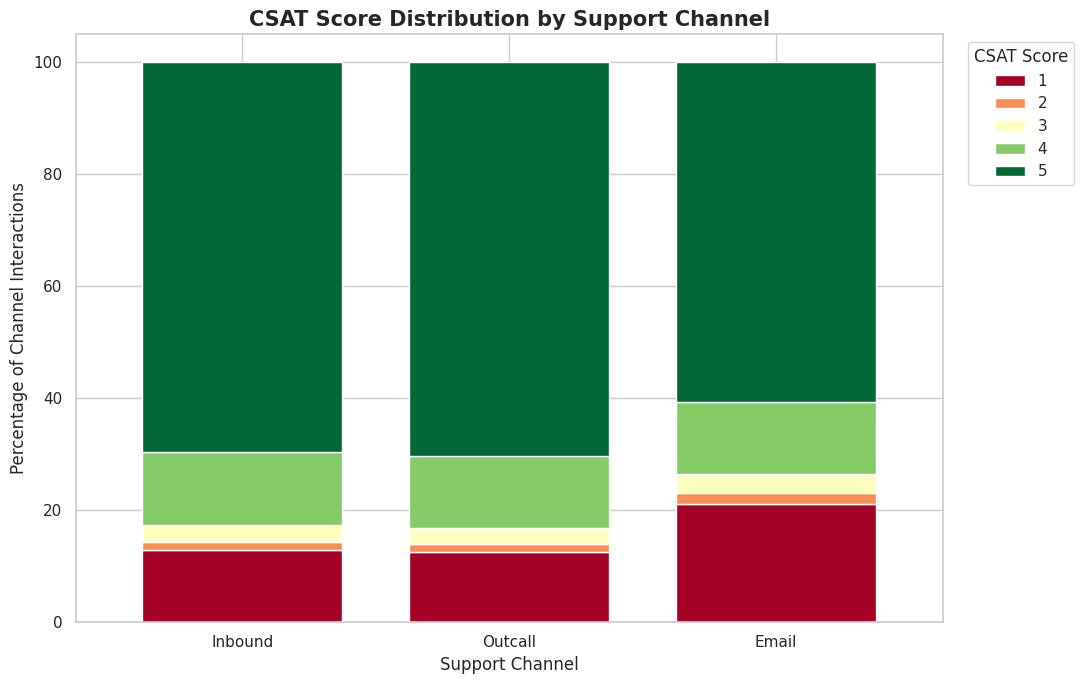

csat_score,1,2,3,4,5
channel_name,,,,,
Inbound,12.83,1.48,2.98,13.11,69.59
Outcall,12.54,1.41,2.87,12.87,70.31
Email,21.04,2.12,3.37,12.83,60.64


In [46]:
channel_csat_percentage = pd.crosstab(
    df_clean["channel_name"],
    df_clean["csat_score"],
    normalize="index"
).mul(100)

channel_csat_percentage = (
    channel_csat_percentage
    .reindex(["Inbound", "Outcall", "Email"])
)

ax = channel_csat_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7),
    colormap="RdYlGn",
    width=0.75
)

plt.title(
    "CSAT Score Distribution by Support Channel",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Support Channel")
plt.ylabel("Percentage of Channel Interactions")
plt.xticks(rotation=0)
plt.legend(
    title="CSAT Score",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

channel_csat_percentage.round(2)

#### 1. Why was this chart selected?

A 100% stacked bar chart compares the relative rating composition of channels
with very different interaction volumes. A count chart would be dominated by
the much larger inbound channel.

#### 2. What insights were found?

Email has the least favourable CSAT distribution. Approximately 21.04% of
email interactions received score 1, compared with 12.83% for inbound and
12.54% for outcall. Only 60.64% of email interactions received score 5,
compared with approximately 70% for the other two channels.

#### 3. What is the potential business impact?

The email-support workflow should be investigated for delayed responses,
limited context, or resolution-quality issues. Channel-specific model
performance must also be reported because the smaller email sample may produce
less reliable predictions despite showing a higher dissatisfaction rate.

### Chart 7: Average CSAT Score by Interaction Category

This chart compares average customer satisfaction across interaction
categories. The accompanying table includes interaction volume and the
percentage of low ratings so that small categories are not over-interpreted.

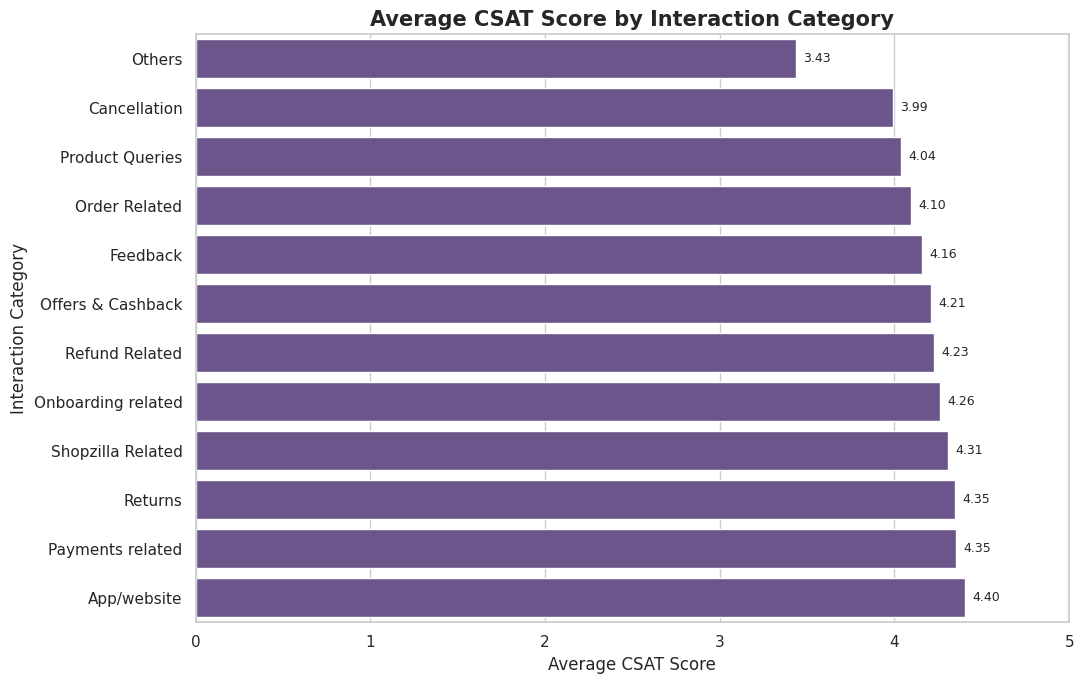

,interaction_count,average_csat,low_csat_percentage
category,,,
Others,99,3.43,33.33
Cancellation,2212,3.99,21.47
Product Queries,3692,4.04,18.26
Order Related,23215,4.10,17.88
Feedback,2294,4.16,16.83
Offers & Cashback,480,4.21,14.79
Refund Related,4550,4.23,15.01
Onboarding related,65,4.26,15.38
Shopzilla Related,2792,4.31,13.32


In [47]:
category_csat_summary = (
    df_clean.groupby("category")
    .agg(
        interaction_count=("csat_score", "size"),
        average_csat=("csat_score", "mean"),
        low_csat_percentage=(
            "csat_score",
            lambda values: values.isin([1, 2]).mean() * 100
        )
    )
    .sort_values("average_csat", ascending=True)
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=category_csat_summary.reset_index(),
    x="average_csat",
    y="category",
    color="#6A4C93"
)

for position, value in enumerate(
    category_csat_summary["average_csat"]
):
    ax.text(
        value + 0.04,
        position,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )

plt.title(
    "Average CSAT Score by Interaction Category",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Average CSAT Score")
plt.ylabel("Interaction Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

category_csat_summary.round(2)

#### 1. Why was this chart selected?

A horizontal bar chart allows average CSAT to be compared across several
interaction categories while keeping the category labels readable. Interaction
counts and low-rating percentages provide necessary context.

#### 2. What insights were found?

Cancellation has an average CSAT of approximately 3.99 and a low-rating rate of
21.47%. Product queries and order-related interactions also have lower average
satisfaction than returns and payment-related interactions. The Others category
has the lowest average, but it contains only 99 records and should be
interpreted cautiously.

#### 3. What is the potential business impact?

Cancellation, product-query, and order-related workflows should be reviewed for
resolution delays, unclear policies, and communication problems. Categories
with very small sample sizes should not drive major business decisions without
additional data.

### Chart 8: Average CSAT Score by Agent Tenure

This chart examines whether customer satisfaction differs across agent-tenure
groups. It helps assess whether experience and training may be associated with
service outcomes.

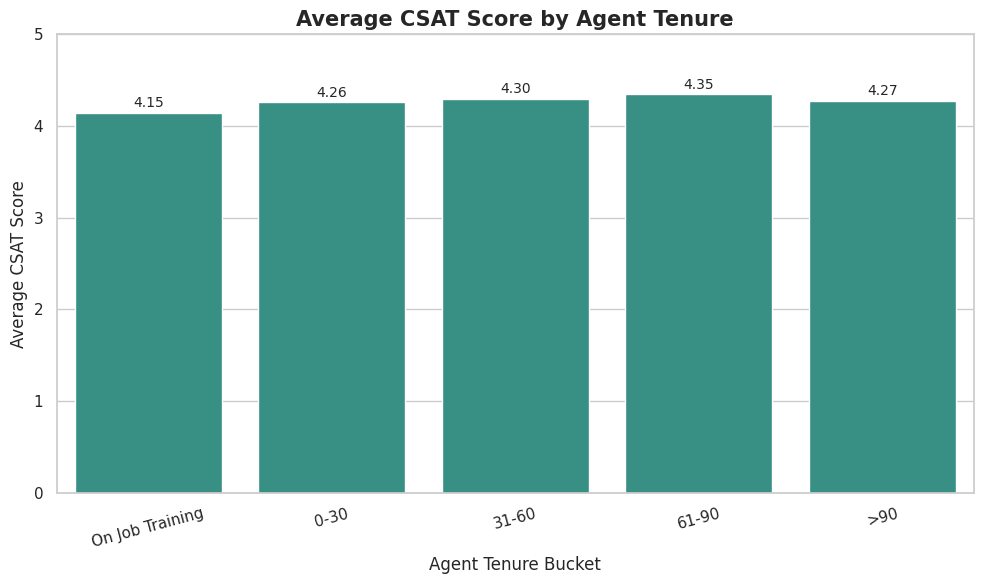

,interaction_count,average_csat,low_csat_percentage
tenure_bucket,,,
On Job Training,25523,4.15,16.64
0-30,11318,4.26,14.07
31-60,11665,4.30,13.37
61-90,6741,4.35,12.16
>90,30660,4.27,14.00


In [48]:
tenure_order = [
    "On Job Training",
    "0-30",
    "31-60",
    "61-90",
    ">90"
]

tenure_csat_summary = (
    df_clean.groupby("tenure_bucket")
    .agg(
        interaction_count=("csat_score", "size"),
        average_csat=("csat_score", "mean"),
        low_csat_percentage=(
            "csat_score",
            lambda values: values.isin([1, 2]).mean() * 100
        )
    )
    .reindex(tenure_order)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=tenure_csat_summary.reset_index(),
    x="tenure_bucket",
    y="average_csat",
    color="#2A9D8F"
)

for position, value in enumerate(
    tenure_csat_summary["average_csat"]
):
    ax.text(
        position,
        value + 0.06,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Average CSAT Score by Agent Tenure",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Agent Tenure Bucket")
plt.ylabel("Average CSAT Score")
plt.ylim(0, 5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

tenure_csat_summary.round(2)

#### 1. Why was this chart selected?

A bar chart provides a direct comparison of average CSAT across the ordered
agent-tenure groups.

#### 2. What insights were found?

Agents in On Job Training have the lowest average CSAT at approximately 4.15
and the highest low-rating percentage at 16.64%. The 61–90 tenure group has the
highest average CSAT at approximately 4.35. Satisfaction does not increase
perfectly with tenure because the above-90 group is slightly lower.

#### 3. What is the potential business impact?

Additional coaching, call monitoring, and knowledge support may help agents
during on-the-job training. The results show an association and do not prove
that tenure alone causes the difference. Category mix, channel, shift, and case
complexity may also affect satisfaction.

### Chart 9: Average CSAT Score by Agent Shift

This chart compares satisfaction across agent shifts to identify possible
time-of-day differences in service performance.

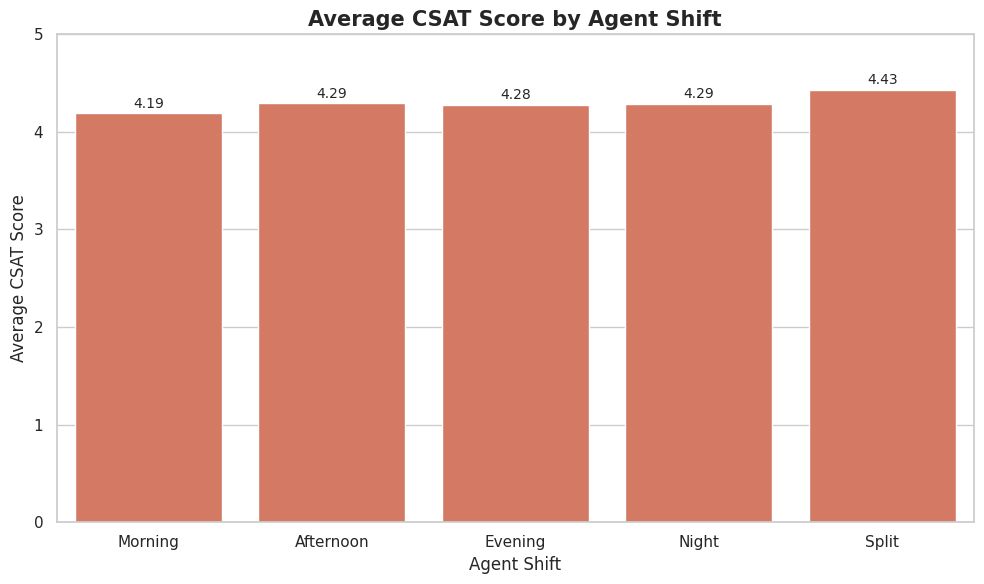

,interaction_count,average_csat,low_csat_percentage
agent_shift,,,
Morning,41426,4.19,15.75
Afternoon,5840,4.29,13.66
Evening,33677,4.28,13.73
Night,1316,4.29,14.44
Split,3648,4.43,10.33


In [49]:
shift_order = [
    "Morning",
    "Afternoon",
    "Evening",
    "Night",
    "Split"
]

shift_csat_summary = (
    df_clean.groupby("agent_shift")
    .agg(
        interaction_count=("csat_score", "size"),
        average_csat=("csat_score", "mean"),
        low_csat_percentage=(
            "csat_score",
            lambda values: values.isin([1, 2]).mean() * 100
        )
    )
    .reindex(shift_order)
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=shift_csat_summary.reset_index(),
    x="agent_shift",
    y="average_csat",
    color="#E76F51"
)

for position, value in enumerate(
    shift_csat_summary["average_csat"]
):
    ax.text(
        position,
        value + 0.06,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Average CSAT Score by Agent Shift",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Agent Shift")
plt.ylabel("Average CSAT Score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

shift_csat_summary.round(2)

#### 1. Why was this chart selected?

A bar chart clearly compares average satisfaction across the five agent-shift
categories.

#### 2. What insights were found?

The morning shift handles the largest volume and has the lowest average CSAT at
approximately 4.19. The split shift has the highest average CSAT at
approximately 4.43 and the lowest low-rating percentage at 10.33%. The night
shift has a smaller sample than the major shifts.

#### 3. What is the potential business impact?

Morning-shift staffing, workload, category mix, and response processes should be
reviewed because this shift handles the highest volume and has comparatively
lower satisfaction. The split-shift result may help identify useful operating
practices, but workload and interaction mix must be considered before making
causal conclusions.

### Chart 10: Customer Satisfaction by Response-Time Bucket

This chart examines how customer satisfaction changes across different support
response-time ranges. Response speed is an actionable operational measure that
may influence the customer's service experience.

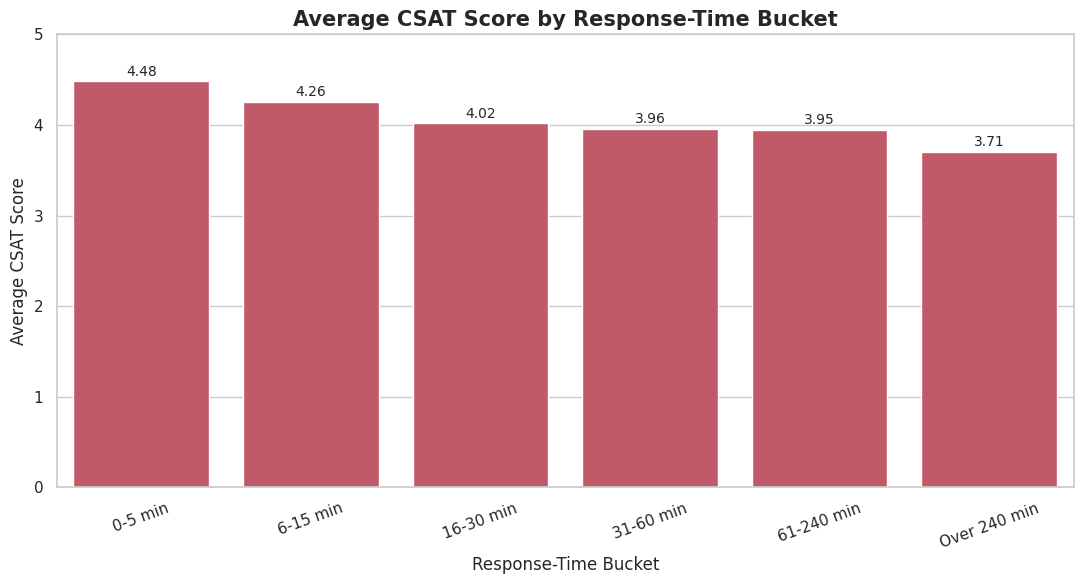

,interaction_count,average_csat,low_csat_percentage
response_time_bucket,,,
0-5 min,40486,4.48,8.88
6-15 min,13886,4.26,13.88
16-30 min,5864,4.02,19.63
31-60 min,4484,3.96,21.07
61-240 min,7399,3.95,21.62
Over 240 min,10660,3.71,27.74


In [50]:
response_time_order = [
    "0-5 min",
    "6-15 min",
    "16-30 min",
    "31-60 min",
    "61-240 min",
    "Over 240 min"
]

df_clean["response_time_bucket"] = pd.cut(
    df_clean["response_time_minutes"],
    bins=[-0.001, 5, 15, 30, 60, 240, np.inf],
    labels=response_time_order
)

response_csat_summary = (
    df_clean.groupby(
        "response_time_bucket",
        observed=False
    )
    .agg(
        interaction_count=("csat_score", "size"),
        average_csat=("csat_score", "mean"),
        low_csat_percentage=(
            "csat_score",
            lambda values: values.isin([1, 2]).mean() * 100
        )
    )
    .reindex(response_time_order)
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=response_csat_summary.reset_index(),
    x="response_time_bucket",
    y="average_csat",
    color="#D1495B"
)

for position, value in enumerate(
    response_csat_summary["average_csat"]
):
    ax.text(
        position,
        value + 0.06,
        f"{value:.2f}",
        ha="center",
        fontsize=10
    )

plt.title(
    "Average CSAT Score by Response-Time Bucket",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Response-Time Bucket")
plt.ylabel("Average CSAT Score")
plt.ylim(0, 5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

response_csat_summary.round(2)

#### 1. Why was this chart selected?

An ordered bar chart clearly compares satisfaction across meaningful
response-time ranges and makes the operational pattern easy to interpret.

#### 2. What insights were found?

Interactions answered within five minutes have an average CSAT of approximately
4.48 and a low-rating rate of 8.88%. Interactions taking more than 240 minutes
have a substantially lower average CSAT of approximately 3.71 and a low-rating
rate of 27.74%.

The chart excludes 3,128 records containing invalid negative response
durations.

#### 3. What is the potential business impact?

Faster responses are associated with higher customer satisfaction. The business
should monitor long-wait cases and establish escalation rules for interactions
approaching critical response-time thresholds. This result shows association;
issue complexity and channel may also influence both response time and CSAT.

### Chart 11: Average CSAT Score by Day of the Week

This chart compares customer satisfaction across reporting weekdays to identify
whether service outcomes vary during the weekly operating cycle.

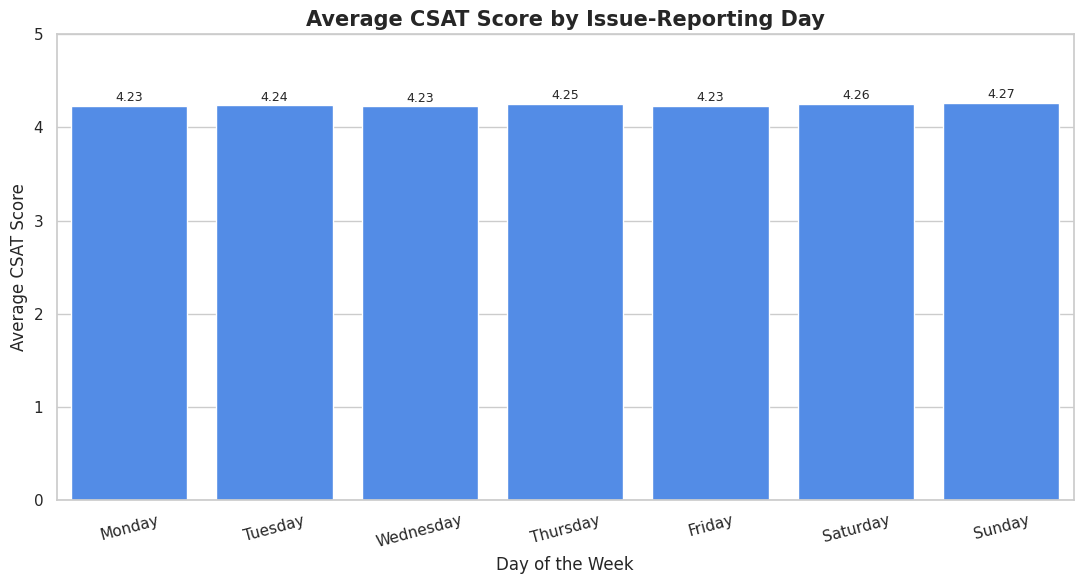

,interaction_count,average_csat,low_csat_percentage
issue_day_of_week,,,
Monday,12053,4.23,14.70
Tuesday,14282,4.24,14.64
Wednesday,13633,4.23,14.82
Thursday,13803,4.25,14.42
Friday,10564,4.23,14.98
Saturday,10630,4.26,14.26
Sunday,10942,4.27,14.07


In [51]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_csat_summary = (
    df_clean.groupby("issue_day_of_week")
    .agg(
        interaction_count=("csat_score", "size"),
        average_csat=("csat_score", "mean"),
        low_csat_percentage=(
            "csat_score",
            lambda values: values.isin([1, 2]).mean() * 100
        )
    )
    .reindex(weekday_order)
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=weekday_csat_summary.reset_index(),
    x="issue_day_of_week",
    y="average_csat",
    color="#3A86FF"
)

for position, value in enumerate(
    weekday_csat_summary["average_csat"]
):
    ax.text(
        position,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )

plt.title(
    "Average CSAT Score by Issue-Reporting Day",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Day of the Week")
plt.ylabel("Average CSAT Score")
plt.ylim(0, 5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

weekday_csat_summary.round(2)

#### 1. Why was this chart selected?

A weekday comparison helps identify recurring operational patterns that may be
linked to workload, staffing, or service availability.

#### 2. What insights were found?

Average CSAT remains relatively stable across all seven days, ranging from
approximately 4.23 to 4.27. Friday has the highest low-rating percentage at
14.98%, while Sunday has the lowest at 14.07%. These differences are small.

#### 3. What is the potential business impact?

The results do not indicate a major weekday-specific satisfaction problem.
Operational improvement should focus more strongly on response time, category,
and channel. Weekday can still be retained as a model feature because it may
interact with other variables.

### Chart 12: Average CSAT Score by Issue-Reporting Period

This chart groups issue-reporting hours into practical time periods and compares
their customer-satisfaction outcomes.

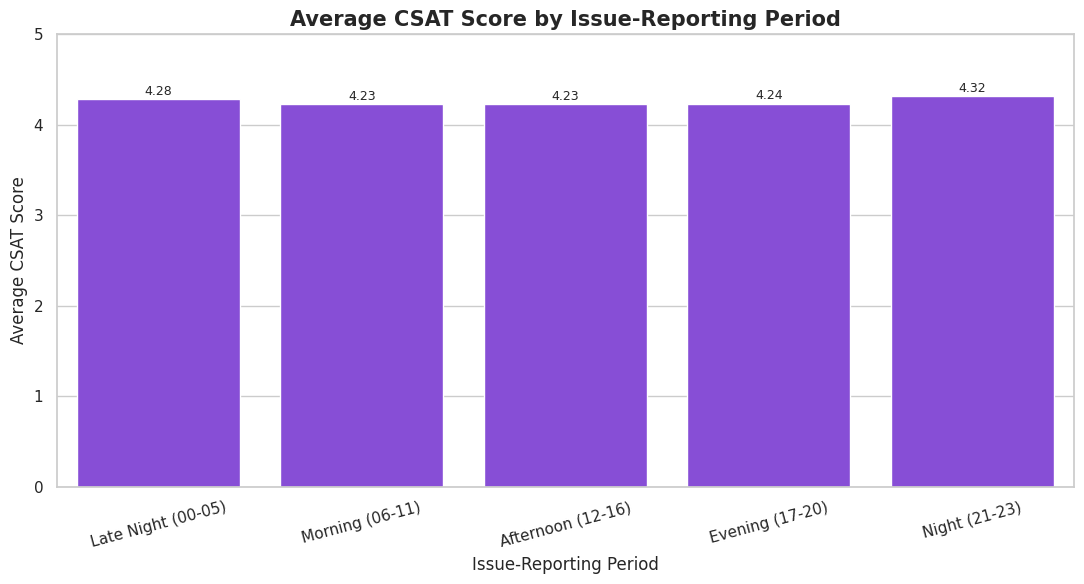

,interaction_count,average_csat,low_csat_percentage
issue_time_period,,,
Late Night (00-05),2402,4.28,14.32
Morning (06-11),22460,4.23,14.71
Afternoon (12-16),26966,4.23,14.86
Evening (17-20),23222,4.24,14.84
Night (21-23),10857,4.32,13.01


In [52]:
time_period_order = [
    "Late Night (00-05)",
    "Morning (06-11)",
    "Afternoon (12-16)",
    "Evening (17-20)",
    "Night (21-23)"
]

df_clean["issue_time_period"] = pd.cut(
    df_clean["issue_hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=time_period_order
)

time_period_csat_summary = (
    df_clean.groupby(
        "issue_time_period",
        observed=False
    )
    .agg(
        interaction_count=("csat_score", "size"),
        average_csat=("csat_score", "mean"),
        low_csat_percentage=(
            "csat_score",
            lambda values: values.isin([1, 2]).mean() * 100
        )
    )
    .reindex(time_period_order)
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=time_period_csat_summary.reset_index(),
    x="issue_time_period",
    y="average_csat",
    color="#8338EC"
)

for position, value in enumerate(
    time_period_csat_summary["average_csat"]
):
    ax.text(
        position,
        value + 0.05,
        f"{value:.2f}",
        ha="center",
        fontsize=9
    )

plt.title(
    "Average CSAT Score by Issue-Reporting Period",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Issue-Reporting Period")
plt.ylabel("Average CSAT Score")
plt.ylim(0, 5)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

time_period_csat_summary.round(2)

#### 1. Why was this chart selected?

Grouping hours into operational time periods is easier to interpret than
comparing 24 individual hourly categories.

#### 2. What insights were found?

Night interactions between 21:00 and 23:00 have the highest average CSAT at
approximately 4.32 and the lowest low-rating percentage at 13.01%. Morning,
afternoon, and evening periods have similar average satisfaction of
approximately 4.23.

#### 3. What is the potential business impact?

Time of day alone does not appear to be a major satisfaction driver. The night
period's stronger result may reflect lower workload or a different interaction
mix. Staffing decisions should therefore consider ticket volume, category, and
channel alongside CSAT.

### Chart 13: Average CSAT Score by Product Category

This chart compares satisfaction across product categories. A known spelling
variation is standardized before aggregation so that the product label remains
clear and professional.

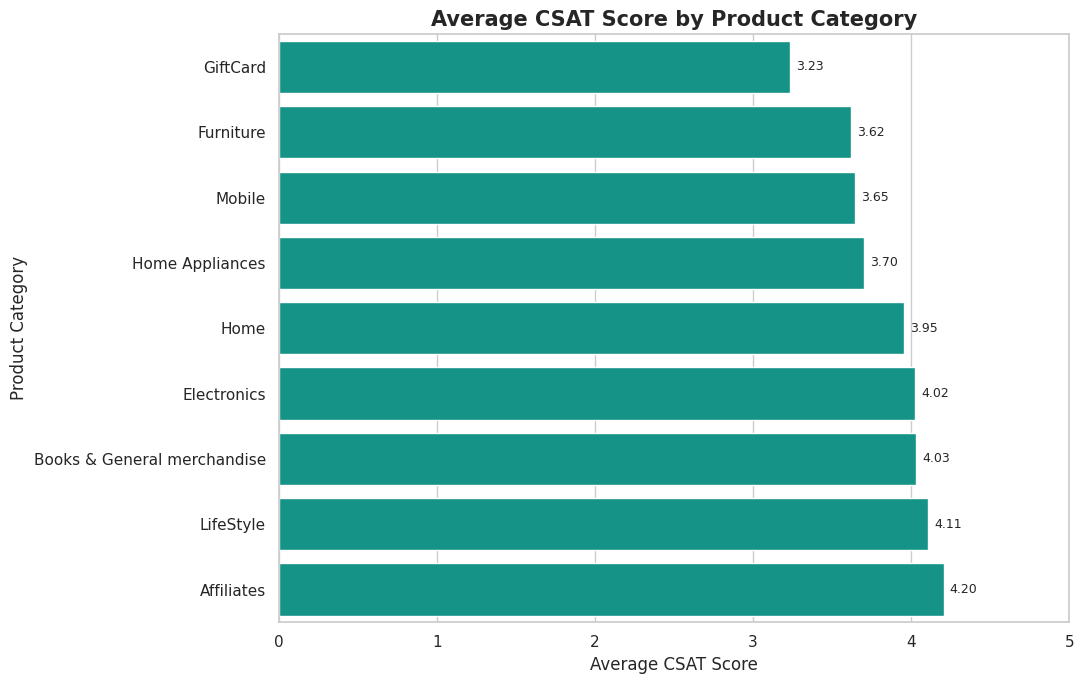

,interaction_count,average_csat,low_csat_percentage
product_category,,,
GiftCard,26,3.23,42.31
Furniture,471,3.62,30.36
Mobile,1758,3.65,30.15
Home Appliances,1300,3.70,28.62
Home,1328,3.95,22.06
Electronics,4706,4.02,19.91
Books & General merchandise,3323,4.03,19.80
LifeStyle,4118,4.11,17.65
Affiliates,166,4.20,15.66


In [53]:
# Correct a known spelling error in the source data.
df_clean["product_category"] = (
    df_clean["product_category"]
    .replace({
        "Home Appliences": "Home Appliances"
    })
)

product_csat_summary = (
    df_clean.groupby("product_category")
    .agg(
        interaction_count=("csat_score", "size"),
        average_csat=("csat_score", "mean"),
        low_csat_percentage=(
            "csat_score",
            lambda values: values.isin([1, 2]).mean() * 100
        )
    )
    .sort_values("average_csat", ascending=True)
)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=product_csat_summary.reset_index(),
    x="average_csat",
    y="product_category",
    color="#00A896"
)

for position, value in enumerate(
    product_csat_summary["average_csat"]
):
    ax.text(
        value + 0.04,
        position,
        f"{value:.2f}",
        va="center",
        fontsize=9
    )

plt.title(
    "Average CSAT Score by Product Category",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel("Average CSAT Score")
plt.ylabel("Product Category")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

product_csat_summary.round(2)

#### 1. Why was this chart selected?

A horizontal bar chart clearly compares average satisfaction across product
categories while keeping longer product labels readable.

#### 2. What insights were found?

Furniture, mobile, and home-appliance interactions have lower average CSAT and
higher low-rating percentages than most other product categories. GiftCard has
the lowest average, but its sample contains only 26 records and is too small for
a strong conclusion.

#### 3. What is the potential business impact?

Mobile, furniture, and home-appliance support processes may require additional
product knowledge, installation support, or clearer resolution procedures.
Small categories should be monitored, but major decisions should be based on
categories with sufficient observations. Product category is missing for
approximately 80% of the full dataset, which limits the generalizability of
these findings.

### Chart 14: Spearman Correlation Heatmap

A Spearman correlation heatmap is used to examine monotonic relationships among
the engineered numerical variables and CSAT Score. Spearman correlation is
preferred because the numerical variables remain non-normal and CSAT is an
ordered score.

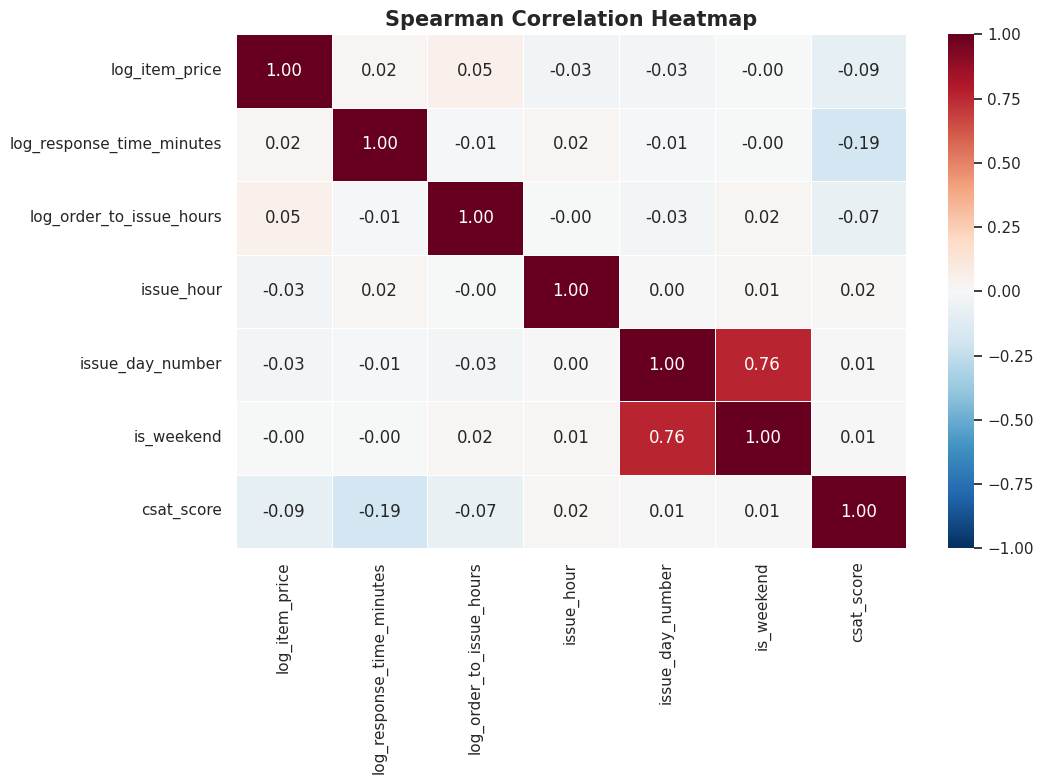

,log_item_price,log_response_time_minutes,log_order_to_issue_hours,issue_hour,issue_day_number,is_weekend,csat_score
log_item_price,1.000,0.021,0.055,-0.034,-0.030,-0.001,-0.093
log_response_time_minutes,0.021,1.000,-0.011,0.020,-0.012,-0.002,-0.185
log_order_to_issue_hours,0.055,-0.011,1.000,-0.004,-0.029,0.016,-0.074
issue_hour,-0.034,0.020,-0.004,1.000,0.004,0.009,0.015
issue_day_number,-0.030,-0.012,-0.029,0.004,1.000,0.759,0.007
is_weekend,-0.001,-0.002,0.016,0.009,0.759,1.000,0.007
csat_score,-0.093,-0.185,-0.074,0.015,0.007,0.007,1.000


In [54]:
correlation_columns = [
    "log_item_price",
    "log_response_time_minutes",
    "log_order_to_issue_hours",
    "issue_hour",
    "issue_day_number",
    "is_weekend",
    "csat_score"
]

spearman_correlation = (
    df_clean[correlation_columns]
    .corr(method="spearman")
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    spearman_correlation,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title(
    "Spearman Correlation Heatmap",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

spearman_correlation.round(3)

#### 1. Why was this chart selected?

A correlation heatmap provides a compact comparison of the direction and
strength of relationships among several numerical variables.

#### 2. What insights were found?

Log response time has the strongest numerical association with CSAT, with a
Spearman correlation of approximately -0.185. This supports the earlier finding
that longer response times are associated with lower satisfaction. Item price
and order-to-issue time have weaker negative correlations with CSAT.

Issue day number and weekend status have a strong correlation because weekend
status is directly derived from the day number.

#### 3. What is the potential business impact?

Response time appears more operationally relevant than reporting hour or
weekday. However, no individual numerical feature has a strong relationship
with CSAT. The ANN is therefore expected to learn combinations and nonlinear
interactions among categorical, numerical, and operational features.
Correlation does not establish causation.

### Chart 15: Pair Plot of Engineered Numerical Features

A pair plot is used to inspect distributions and pairwise relationships among
the main transformed numerical features. A reproducible sample is used to keep
the visualization readable and computationally efficient.

Complete records available for pair plot: 16833
Pair plot sample size: 3000


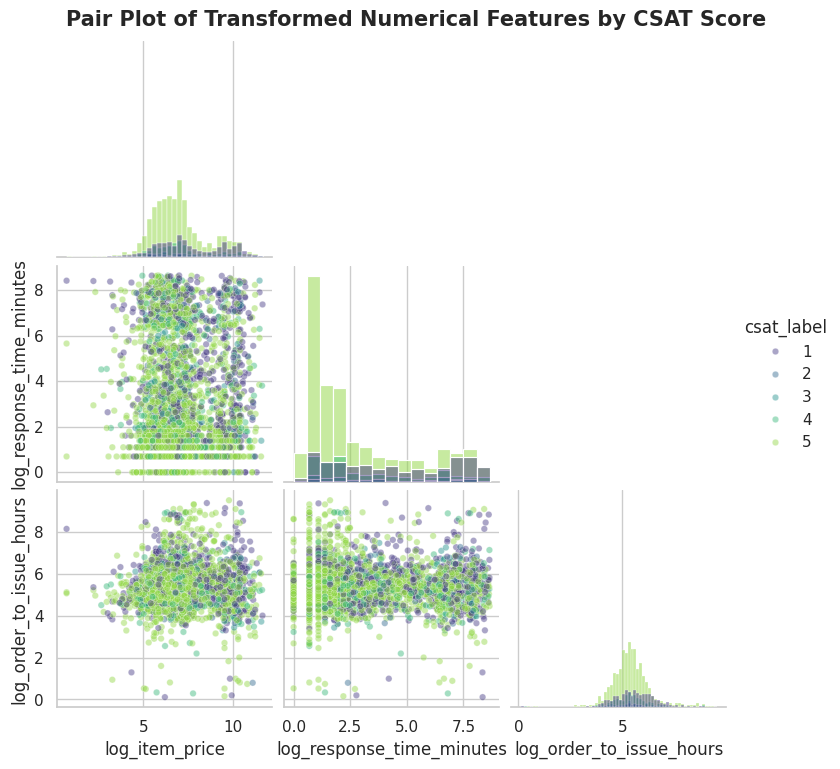

In [55]:
pairplot_columns = [
    "log_item_price",
    "log_response_time_minutes",
    "log_order_to_issue_hours",
    "csat_score"
]

pairplot_data = (
    df_clean[pairplot_columns]
    .dropna()
    .sample(
        n=min(3000, df_clean[pairplot_columns].dropna().shape[0]),
        random_state=RANDOM_STATE
    )
    .copy()
)

pairplot_data["csat_label"] = (
    pairplot_data["csat_score"]
    .astype(int)
    .astype(str)
)

print(
    "Complete records available for pair plot:",
    df_clean[pairplot_columns].dropna().shape[0]
)
print(
    "Pair plot sample size:",
    pairplot_data.shape[0]
)

pair_grid = sns.pairplot(
    data=pairplot_data,
    vars=[
        "log_item_price",
        "log_response_time_minutes",
        "log_order_to_issue_hours"
    ],
    hue="csat_label",
    hue_order=["1", "2", "3", "4", "5"],
    corner=True,
    diag_kind="hist",
    palette="viridis",
    plot_kws={
        "alpha": 0.45,
        "s": 22
    }
)

pair_grid.fig.suptitle(
    "Pair Plot of Transformed Numerical Features by CSAT Score",
    y=1.02,
    fontsize=15,
    fontweight="bold"
)

plt.show()

#### 1. Why was this chart selected?

A pair plot simultaneously shows the distribution of each numerical feature
and the relationship between every pair of selected features. Sampling keeps
the plot readable without changing the original modeling dataset.

#### 2. What insights were found?

The transformed features are considerably less skewed than their raw versions,
but the five CSAT classes still overlap substantially. No pair of numerical
features provides a clear visual separation between satisfaction classes.
Scores 2 and 3 are visibly less frequent because of target imbalance.

#### 3. What is the potential business impact?

Numerical variables alone are unlikely to classify all five CSAT scores
accurately. Categorical variables such as category, sub-category, channel,
tenure, and shift will be important model inputs. The overlap also supports
using a nonlinear model while retaining realistic expectations about prediction
accuracy.

## 5. Hypothesis Testing

### Hypothetical Statement 1: Support Channel and CSAT Score

**Null Hypothesis (H₀):** Support channel and CSAT score are independent. The
distribution of customer-satisfaction scores does not differ by support channel.

**Alternative Hypothesis (H₁):** Support channel and CSAT score are associated.
At least one support channel has a different CSAT distribution.

A Chi-Square Test of Independence is used because both support channel and CSAT
score are categorical variables. Cramér's V is also calculated to measure the
practical strength of the association.

In [56]:
channel_csat_table = pd.crosstab(
    df_clean["channel_name"],
    df_clean["csat_score"]
)

chi_square_statistic, channel_p_value, degrees_of_freedom, expected_counts = (
    stats.chi2_contingency(channel_csat_table)
)

total_observations = channel_csat_table.to_numpy().sum()
minimum_dimension = min(channel_csat_table.shape)

cramers_v = np.sqrt(
    chi_square_statistic
    / (
        total_observations
        * (minimum_dimension - 1)
    )
)

alpha = 0.05

print("Chi-Square Test: Support Channel vs CSAT")
print("-" * 45)
print(f"Chi-square statistic: {chi_square_statistic:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {channel_p_value:.3e}")
print(f"Cramer's V: {cramers_v:.4f}")
print(f"Minimum expected frequency: {expected_counts.min():.2f}")

if channel_p_value < alpha:
    print("Decision: Reject the null hypothesis.")
else:
    print("Decision: Fail to reject the null hypothesis.")

Chi-Square Test: Support Channel vs CSAT
---------------------------------------------
Chi-square statistic: 199.9119
Degrees of freedom: 8
P-value: 6.669e-39
Cramer's V: 0.0341
Minimum expected frequency: 45.15
Decision: Reject the null hypothesis.


#### Which statistical test was performed?

A Chi-Square Test of Independence was performed because both variables are
categorical. The minimum expected cell frequency is greater than five, so the
expected-frequency requirement is satisfied.

#### Why was this test selected?

The test determines whether the distribution of CSAT scores differs across
inbound, outcall, and email channels.

#### Conclusion

The p-value is substantially below 0.05, so the null hypothesis is rejected.
Support channel and CSAT distribution have a statistically significant
association. However, Cramér's V is approximately 0.034, indicating that the
practical association is weak. The large dataset can make small differences
statistically significant.

Email has a less favourable CSAT distribution, but channel alone is unlikely to
explain customer satisfaction.

### Hypothetical Statement 2: Agent Tenure and CSAT Score

**Null Hypothesis (H₀):** The distribution of CSAT scores is the same across all
agent-tenure groups.

**Alternative Hypothesis (H₁):** At least one agent-tenure group has a different
CSAT distribution.

A Kruskal-Wallis H test is used because CSAT is an ordered discrete score and
the analysis compares more than two independent tenure groups. Epsilon-squared
is calculated as an effect-size estimate.

In [57]:
tenure_groups = [
    df_clean.loc[
        df_clean["tenure_bucket"] == tenure,
        "csat_score"
    ].dropna()
    for tenure in tenure_order
]

kruskal_statistic, tenure_p_value = stats.kruskal(
    *tenure_groups
)

number_of_groups = len(tenure_groups)
total_tenure_records = sum(
    len(group) for group in tenure_groups
)

epsilon_squared = (
    kruskal_statistic - number_of_groups + 1
) / (
    total_tenure_records - number_of_groups
)

print("Kruskal-Wallis Test: Agent Tenure vs CSAT")
print("-" * 47)
print(f"Kruskal-Wallis statistic: {kruskal_statistic:.4f}")
print(f"Number of tenure groups: {number_of_groups}")
print(f"Sample size: {total_tenure_records:,}")
print(f"P-value: {tenure_p_value:.3e}")
print(f"Epsilon-squared: {epsilon_squared:.5f}")

if tenure_p_value < alpha:
    print("Decision: Reject the null hypothesis.")
else:
    print("Decision: Fail to reject the null hypothesis.")

Kruskal-Wallis Test: Agent Tenure vs CSAT
-----------------------------------------------
Kruskal-Wallis statistic: 223.4554
Number of tenure groups: 5
Sample size: 85,907
P-value: 3.383e-47
Epsilon-squared: 0.00255
Decision: Reject the null hypothesis.


#### Which statistical test was performed?

A Kruskal-Wallis H test was performed. It is a non-parametric test for comparing
the distributions of more than two independent groups.

#### Why was this test selected?

There are five agent-tenure groups, and CSAT is an ordered score with a strongly
imbalanced and non-normal distribution. Therefore, a one-way ANOVA would not be
the preferred primary test.

#### Conclusion

The p-value is below 0.05, so the null hypothesis is rejected. CSAT
distributions differ statistically across tenure groups. However,
epsilon-squared is approximately 0.00255, indicating a very small effect.

Agent tenure may contribute some predictive information, but it should not be
treated as a dominant driver of customer satisfaction. Category, channel,
workload, and response time may explain more of the observed variation.

### Hypothetical Statement 3: Response Time and CSAT Score

**Null Hypothesis (H₀):** There is no monotonic relationship between response
time and CSAT score.

**Alternative Hypothesis (H₁):** Response time and CSAT score have a monotonic
relationship.

Spearman's rank correlation is used because response time is highly skewed and
CSAT is an ordered score. The test does not require normally distributed
variables.

In [58]:
response_test_data = df_clean[
    [
        "response_time_minutes",
        "csat_score"
    ]
].dropna()

spearman_rho, response_p_value = stats.spearmanr(
    response_test_data["response_time_minutes"],
    response_test_data["csat_score"]
)

print("Spearman Correlation: Response Time vs CSAT")
print("-" * 48)
print(f"Sample size: {len(response_test_data):,}")
print(f"Spearman correlation: {spearman_rho:.4f}")
print(f"P-value: {response_p_value:.3e}")

if response_p_value < alpha:
    print("Decision: Reject the null hypothesis.")
else:
    print("Decision: Fail to reject the null hypothesis.")

Spearman Correlation: Response Time vs CSAT
------------------------------------------------
Sample size: 82,779
Spearman correlation: -0.1854
P-value: 0.000e+00
Decision: Reject the null hypothesis.


#### Which statistical test was performed?

Spearman's rank-order correlation test was performed to measure the monotonic
association between response time and CSAT score.

#### Why was this test selected?

Response time is highly right-skewed, contains extreme values, and does not meet
the assumptions of Pearson correlation. CSAT is also an ordered discrete score.
Spearman correlation is therefore more appropriate.

#### Conclusion

The p-value is below 0.05, so the null hypothesis is rejected. Response time and
CSAT have a statistically significant negative relationship. The Spearman
correlation of approximately -0.185 indicates that longer response times tend
to be associated with lower satisfaction.

The relationship is meaningful but not strong enough to explain CSAT by itself.
This result supports including response time in the ANN while combining it with
interaction, channel, agent, and temporal features.

## 6. Feature Engineering and Data Preprocessing

### Final Feature Groups for the Primary ANN Model

The selected variables are divided into numerical, low-cardinality categorical,
and high-cardinality categorical groups. Identifiers, raw timestamps,
post-survey information, and highly incomplete variables are excluded from the
primary model.

In [59]:
model_numeric_features = [
    "log_item_price",
    "log_response_time_minutes",
    "log_order_to_issue_hours",
    "issue_hour",
    "issue_day_number",
    "is_weekend",
    "invalid_response_time",
    "invalid_order_to_issue_time",
    "is_order_id_missing",
    "is_order_date_time_missing",
    "is_customer_remarks_missing",
    "is_customer_city_missing",
    "is_product_category_missing",
    "is_item_price_missing"
]

low_cardinality_features = [
    "channel_name",
    "category",
    "sub_category",
    "product_category",
    "supervisor",
    "manager",
    "tenure_bucket",
    "agent_shift"
]

high_cardinality_features = [
    "customer_city",
    "agent_name"
]

model_features = (
    model_numeric_features
    + low_cardinality_features
    + high_cardinality_features
)

model_data = df_clean[
    model_features
    + ["csat_score", "issue_reported_at"]
].copy()

print("Numerical features:", len(model_numeric_features))
print("Low-cardinality categorical features:",
      len(low_cardinality_features))
print("High-cardinality categorical features:",
      len(high_cardinality_features))
print("Total model features:", len(model_features))
print("Modeling dataset shape:", model_data.shape)

Numerical features: 14
Low-cardinality categorical features: 8
High-cardinality categorical features: 2
Total model features: 24
Modeling dataset shape: (85907, 26)


### Chronological Train, Validation, and Test Split

The data is divided chronologically to simulate real deployment. Earlier
interactions are used for training, subsequent interactions for validation,
and the latest interactions for final testing.

Preprocessing will be learned only from the training data and then applied to
validation and test data to prevent data leakage.

In [60]:
train_end_date = pd.Timestamp("2023-08-23")
validation_end_date = pd.Timestamp("2023-08-28")

train_data = model_data[
    model_data["issue_reported_at"] < train_end_date
].copy()

validation_data = model_data[
    (model_data["issue_reported_at"] >= train_end_date)
    & (model_data["issue_reported_at"] < validation_end_date)
].copy()

test_data = model_data[
    model_data["issue_reported_at"] >= validation_end_date
].copy()

X_train = train_data[model_features].copy()
y_train = train_data["csat_score"].copy()

X_validation = validation_data[model_features].copy()
y_validation = validation_data["csat_score"].copy()

X_test = test_data[model_features].copy()
y_test = test_data["csat_score"].copy()

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_validation.shape)
print("Test set shape:", X_test.shape)

print("\nTraining period:")
print(
    train_data["issue_reported_at"].min(),
    "to",
    train_data["issue_reported_at"].max()
)

print("\nValidation period:")
print(
    validation_data["issue_reported_at"].min(),
    "to",
    validation_data["issue_reported_at"].max()
)

print("\nTest period:")
print(
    test_data["issue_reported_at"].min(),
    "to",
    test_data["issue_reported_at"].max()
)

Training set shape: (59639, 24)
Validation set shape: (14873, 24)
Test set shape: (11395, 24)

Training period:
2023-07-28 20:42:00 to 2023-08-22 23:59:00

Validation period:
2023-08-23 00:01:00 to 2023-08-27 23:49:00

Test period:
2023-08-28 00:09:00 to 2023-08-31 23:58:00


### Split Validation and Target Distribution

The chronological boundaries and class distributions are validated to confirm
that the three datasets do not overlap and that every CSAT class remains
represented in training, validation, and testing.

In [61]:
chronological_split_valid = (
    train_data["issue_reported_at"].max()
    < validation_data["issue_reported_at"].min()
    and validation_data["issue_reported_at"].max()
    < test_data["issue_reported_at"].min()
)

split_sizes = (
    len(train_data)
    + len(validation_data)
    + len(test_data)
)

target_distribution_by_split = pd.DataFrame({
    "Training (%)": (
        y_train.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),
    "Validation (%)": (
        y_validation.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    ),
    "Test (%)": (
        y_test.value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )
}).round(2)

print("Chronological boundaries valid:",
      chronological_split_valid)

print(
    "All records assigned exactly once:",
    split_sizes == len(model_data)
)

print("\nTarget distribution by split:")
display(target_distribution_by_split)

Chronological boundaries valid: True
All records assigned exactly once: True

Target distribution by split:


,Training (%),Validation (%),Test (%)
csat_score,,,
1,13.96,11.46,10.55
2,1.57,1.28,1.35
3,3.12,2.74,2.54
4,12.72,14.09,13.48
5,68.63,70.43,72.08


### Frequency Encoding of High-Cardinality Variables

Customer city and agent name contain many distinct categories. Direct one-hot
encoding would create thousands of input columns. These variables are therefore
converted into training-frequency features.

The frequency mappings are learned only from the training set. Unseen
validation or test categories receive a frequency of zero.

In [62]:
frequency_maps = {}

for column in high_cardinality_features:
    training_values = (
        X_train[column]
        .fillna("__MISSING__")
    )

    frequency_maps[column] = (
        training_values
        .value_counts(normalize=True)
    )


def apply_frequency_encoding(data, mappings):
    encoded_data = data.copy()

    for column, frequency_map in mappings.items():
        prepared_values = (
            encoded_data[column]
            .fillna("__MISSING__")
        )

        encoded_data[f"{column}_frequency"] = (
            prepared_values
            .map(frequency_map)
            .fillna(0.0)
            .astype(float)
        )

    encoded_data = encoded_data.drop(
        columns=high_cardinality_features
    )

    return encoded_data


X_train_encoded = apply_frequency_encoding(
    X_train,
    frequency_maps
)

X_validation_encoded = apply_frequency_encoding(
    X_validation,
    frequency_maps
)

X_test_encoded = apply_frequency_encoding(
    X_test,
    frequency_maps
)

print(
    "Training city categories:",
    len(frequency_maps["customer_city"])
)
print(
    "Training agent categories:",
    len(frequency_maps["agent_name"])
)

print(
    "Unseen validation cities:",
    (X_validation_encoded["customer_city_frequency"] == 0).sum()
)
print(
    "Unseen test cities:",
    (X_test_encoded["customer_city_frequency"] == 0).sum()
)
print(
    "Unseen validation agents:",
    (X_validation_encoded["agent_name_frequency"] == 0).sum()
)
print(
    "Unseen test agents:",
    (X_test_encoded["agent_name_frequency"] == 0).sum()
)

print("\nEncoded training shape:", X_train_encoded.shape)
print("Encoded validation shape:", X_validation_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Training city categories: 1628
Training agent categories: 1364
Unseen validation cities: 103
Unseen test cities: 81
Unseen validation agents: 153
Unseen test agents: 323

Encoded training shape: (59639, 24)
Encoded validation shape: (14873, 24)
Encoded test shape: (11395, 24)


### Encoding the Target Variable

The original CSAT labels range from 1 to 5. Sparse categorical
cross-entropy expects zero-based class labels, so the target is converted
from 1–5 into 0–4.

The original business scores will be restored after prediction.

In [63]:
y_train_ann = (
    y_train.astype(int) - 1
)

y_validation_ann = (
    y_validation.astype(int) - 1
)

y_test_ann = (
    y_test.astype(int) - 1
)

target_mapping = pd.DataFrame({
    "Original CSAT Score": [1, 2, 3, 4, 5],
    "ANN Class Label": [0, 1, 2, 3, 4]
})

print("Target mapping:")
display(target_mapping)

print(
    "Training ANN labels:",
    sorted(y_train_ann.unique())
)
print(
    "Validation ANN labels:",
    sorted(y_validation_ann.unique())
)
print(
    "Test ANN labels:",
    sorted(y_test_ann.unique())
)
print(
    "Number of classes:",
    y_train_ann.nunique()
)

print("\nOriginal training-score counts:")
print(y_train.value_counts().sort_index())

Target mapping:


,Original CSAT Score,ANN Class Label
0,1,0
1,2,1
2,3,2
3,4,3
4,5,4


Training ANN labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Validation ANN labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Test ANN labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Number of classes: 5

Original training-score counts:
csat_score
1     8324
2      938
3     1861
4     7588
5    40928
Name: count, dtype: int64


### Leakage-Free Preprocessing Pipeline

Numerical variables are imputed using training-set medians and standardized.
Low-cardinality categorical variables are imputed using the most frequent
training value and one-hot encoded.

The preprocessing pipeline is fitted only on the training set. The learned
transformations are then applied unchanged to validation and test data.

### Compatibility Fix for Missing Categorical Values

Pandas missing values in categorical columns are converted from `pd.NA` to
NumPy `np.nan`. This ensures compatibility with Scikit-learn's categorical
imputation pipeline without changing any non-missing category values.

In [65]:
def convert_categorical_missing_values(data):
    corrected_data = data.copy()

    for column in low_cardinality_features:
        corrected_data[column] = (
            corrected_data[column]
            .astype(object)
            .where(
                corrected_data[column].notna(),
                np.nan
            )
        )

    return corrected_data


X_train_encoded = convert_categorical_missing_values(
    X_train_encoded
)

X_validation_encoded = convert_categorical_missing_values(
    X_validation_encoded
)

X_test_encoded = convert_categorical_missing_values(
    X_test_encoded
)

remaining_pd_na = sum(
    value is pd.NA
    for dataframe in [
        X_train_encoded,
        X_validation_encoded,
        X_test_encoded
    ]
    for value in dataframe[
        low_cardinality_features
    ].to_numpy().ravel()
)

print(
    "Pandas pd.NA values remaining in categorical features:",
    remaining_pd_na
)

print("Training data prepared:", X_train_encoded.shape)
print("Validation data prepared:", X_validation_encoded.shape)
print("Test data prepared:", X_test_encoded.shape)

Pandas pd.NA values remaining in categorical features: 0
Training data prepared: (59639, 24)
Validation data prepared: (14873, 24)
Test data prepared: (11395, 24)


In [66]:
encoded_numeric_features = (
    model_numeric_features
    + [
        "customer_city_frequency",
        "agent_name_frequency"
    ]
)

numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            encoded_numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            low_cardinality_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_preprocessed = preprocessor.fit_transform(
    X_train_encoded
)

X_validation_preprocessed = preprocessor.transform(
    X_validation_encoded
)

X_test_preprocessed = preprocessor.transform(
    X_test_encoded
)

processed_feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    "Preprocessed training shape:",
    X_train_preprocessed.shape
)
print(
    "Preprocessed validation shape:",
    X_validation_preprocessed.shape
)
print(
    "Preprocessed test shape:",
    X_test_preprocessed.shape
)

print(
    "Number of processed features:",
    len(processed_feature_names)
)

print(
    "Missing values in training array:",
    np.isnan(X_train_preprocessed).sum()
)
print(
    "Missing values in validation array:",
    np.isnan(X_validation_preprocessed).sum()
)
print(
    "Missing values in test array:",
    np.isnan(X_test_preprocessed).sum()
)

Preprocessed training shape: (59639, 153)
Preprocessed validation shape: (14873, 153)
Preprocessed test shape: (11395, 153)
Number of processed features: 153
Missing values in training array: 0
Missing values in validation array: 0
Missing values in test array: 0


## 7. Model Implementation

### Baseline Model: Majority-Class Prediction

A majority-class baseline predicts the most frequent training class for every
validation record. Any useful machine-learning model should provide meaningful
improvement over this simple benchmark, especially for minority CSAT classes.

In [67]:
majority_csat_score = int(
    y_train.value_counts().idxmax()
)

majority_predictions = np.full(
    shape=len(y_validation),
    fill_value=majority_csat_score
)

majority_baseline_metrics = {
    "Accuracy": accuracy_score(
        y_validation,
        majority_predictions
    ),
    "Macro Precision": precision_score(
        y_validation,
        majority_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_validation,
        majority_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_validation,
        majority_predictions,
        average="macro",
        zero_division=0
    ),
    "MAE": mean_absolute_error(
        y_validation,
        majority_predictions
    ),
    "Quadratic Weighted Kappa": cohen_kappa_score(
        y_validation,
        majority_predictions,
        weights="quadratic"
    )
}

majority_baseline_table = pd.DataFrame(
    majority_baseline_metrics,
    index=["Majority Baseline"]
).T

print(
    "Majority class selected from training data:",
    majority_csat_score
)

majority_baseline_table.round(4)

Majority class selected from training data: 5


,Majority Baseline
Accuracy,0.7043
Macro Precision,0.1409
Macro Recall,0.2000
Macro F1,0.1653
MAE,0.6925
Quadratic Weighted Kappa,0.0000


### Class Weights for Imbalanced Training

Balanced class weights are calculated from the training data. Rare CSAT
classes receive larger weights so that errors on minority classes contribute
more strongly to the training loss.

In [68]:
from sklearn.utils.class_weight import compute_class_weight

ann_classes = np.unique(y_train_ann)

calculated_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=ann_classes,
    y=y_train_ann
)

class_weight_dictionary = {
    int(class_label): float(class_weight)
    for class_label, class_weight in zip(
        ann_classes,
        calculated_class_weights
    )
}

class_weight_table = pd.DataFrame({
    "ANN Class": ann_classes,
    "Original CSAT Score": ann_classes + 1,
    "Training Count": [
        (y_train_ann == class_label).sum()
        for class_label in ann_classes
    ],
    "Class Weight": calculated_class_weights
})

display(class_weight_table.round(4))
print("Class-weight dictionary:")
print(class_weight_dictionary)

,ANN Class,Original CSAT Score,Training Count,Class Weight
0,0,1,8324,1.4329
1,1,2,938,12.7162
2,2,3,1861,6.4093
3,3,4,7588,1.5719
4,4,5,40928,0.2914


Class-weight dictionary:
{0: 1.4329408938010573, 1: 12.716204690831557, 2: 6.40934981192907, 3: 1.5719293621507644, 4: 0.2914337372947615}


### Artificial Neural Network Architecture

A feed-forward neural network is developed for five-class CSAT prediction.
The architecture uses progressively smaller dense layers, batch normalization,
dropout regularization, and a five-neuron softmax output layer.

ReLU activation captures nonlinear relationships. Batch normalization
stabilizes training, while dropout reduces overfitting.

In [69]:
tf.keras.backend.clear_session()

input_dimension = X_train_preprocessed.shape[1]
number_of_classes = 5

ann_model = keras.Sequential(
    [
        keras.Input(
            shape=(input_dimension,),
            name="processed_features"
        ),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001),
            name="dense_128"
        ),
        layers.BatchNormalization(
            name="batch_norm_128"
        ),
        layers.Dropout(
            0.30,
            name="dropout_30"
        ),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001),
            name="dense_64"
        ),
        layers.BatchNormalization(
            name="batch_norm_64"
        ),
        layers.Dropout(
            0.20,
            name="dropout_20"
        ),

        layers.Dense(
            32,
            activation="relu",
            name="dense_32"
        ),

        layers.Dense(
            number_of_classes,
            activation="softmax",
            name="csat_probabilities"
        )
    ],
    name="DeepCSAT_ANN"
)

ann_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "DeepCSAT_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_128                  │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_64                   │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ csat_probabilities (Dense)      │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,981 (121.02 KB)

 Trainable params: 30,597 (119.52 KB)

 Non-trainable params: 384 (1.50 KB)

### Training Configuration and Optimization Callbacks

The processed arrays are converted to float32 to reduce memory usage and improve
TensorFlow training efficiency. Early stopping prevents unnecessary training,
learning-rate reduction helps the optimizer move beyond performance plateaus,
and model checkpointing saves the best validation-loss model.

In [70]:
# Convert model inputs to TensorFlow-friendly float32 arrays.
X_train_ann = X_train_preprocessed.astype(np.float32)
X_validation_ann = X_validation_preprocessed.astype(np.float32)
X_test_ann = X_test_preprocessed.astype(np.float32)

model_directory = (
    "/content/drive/MyDrive/"
    "DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/"
    "models"
)

os.makedirs(
    model_directory,
    exist_ok=True
)

best_model_path = os.path.join(
    model_directory,
    "best_deepcsat_ann.keras"
)

training_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("Training array shape:", X_train_ann.shape)
print("Validation array shape:", X_validation_ann.shape)
print("Test array shape:", X_test_ann.shape)
print("Training data type:", X_train_ann.dtype)
print("Best model path:", best_model_path)

Training array shape: (59639, 153)
Validation array shape: (14873, 153)
Test array shape: (11395, 153)
Training data type: float32
Best model path: /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_ann.keras


### ANN Model Training

The ANN is trained using mini-batches and balanced class weights. Validation
data is used only to monitor generalization and select the best training epoch.
The test set remains untouched for final evaluation.

In [71]:
history = ann_model.fit(
    X_train_ann,
    y_train_ann.to_numpy(),

    validation_data=(
        X_validation_ann,
        y_validation_ann.to_numpy()
    ),

    epochs=60,
    batch_size=256,

    class_weight=class_weight_dictionary,
    callbacks=training_callbacks,

    verbose=1
)

Epoch 1/60
229/233 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2298 - loss: 1.7773
Epoch 1: val_loss improved from None to 1.58028, saving model to /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_ann.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_ann.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.2496 - loss: 1.7032 - val_accuracy: 0.2815 - val_loss: 1.5803 - learning_rate: 0.0010
Epoch 2/60
226/233 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2894 - loss: 1.6146
Epoch 2: val_loss improved from 1.58028 to 1.53284, saving model to /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_ann.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_ann.keras
233/233 ━━━━━━━━━━━━━

### Training and Validation Performance

Training curves are examined to identify convergence and possible overfitting.
The best epoch is selected using the lowest validation loss rather than the
highest training accuracy.

Epochs completed: 13
Best epoch: 5
Best validation loss: 1.5192
Validation accuracy at best epoch: 0.3336


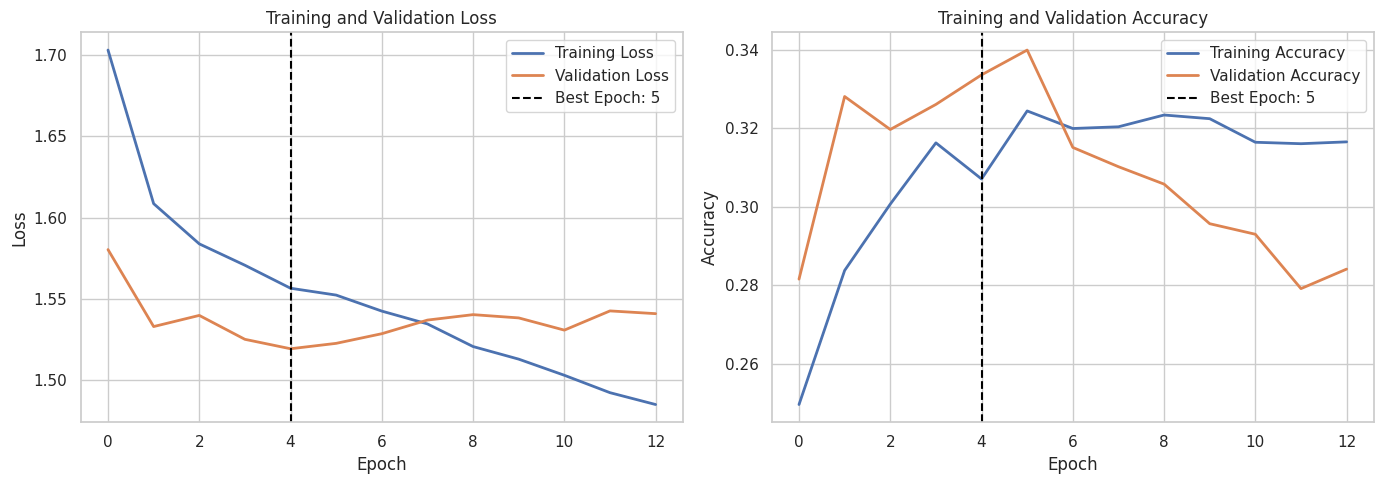

In [72]:
training_history = pd.DataFrame(
    history.history
)

best_epoch = int(
    training_history["val_loss"].idxmin() + 1
)

best_validation_loss = (
    training_history["val_loss"].min()
)

best_validation_accuracy = training_history.loc[
    best_epoch - 1,
    "val_accuracy"
]

print(
    "Epochs completed:",
    len(training_history)
)
print(
    "Best epoch:",
    best_epoch
)
print(
    f"Best validation loss: {best_validation_loss:.4f}"
)
print(
    f"Validation accuracy at best epoch: "
    f"{best_validation_accuracy:.4f}"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].plot(
    training_history["loss"],
    label="Training Loss",
    linewidth=2
)
axes[0].plot(
    training_history["val_loss"],
    label="Validation Loss",
    linewidth=2
)
axes[0].axvline(
    best_epoch - 1,
    color="black",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    training_history["accuracy"],
    label="Training Accuracy",
    linewidth=2
)
axes[1].plot(
    training_history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)
axes[1].axvline(
    best_epoch - 1,
    color="black",
    linestyle="--",
    label=f"Best Epoch: {best_epoch}"
)
axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

### Training-Curve Interpretation

Training completed after 13 epochs, and the lowest validation loss was obtained
at epoch 5. Validation performance deteriorated after the best epoch, indicating
the beginning of overfitting. Early stopping prevented additional unnecessary
training and restored the weights associated with the lowest validation loss.

The validation accuracy at the best-loss epoch was approximately 33.36%.
Accuracy alone is not sufficient for judging this model because balanced class
weights intentionally force the network to pay greater attention to rare CSAT
scores. Macro-F1, class-wise recall, MAE, and quadratic weighted kappa are
therefore required before deciding whether the weighted ANN is useful.

### Loading the Best Weighted ANN and Generating Validation Predictions

The model checkpoint with the lowest validation loss is loaded from Google
Drive. Class probabilities are converted into ANN class labels and then restored
to the original CSAT scale from 1 to 5.

In [73]:
best_weighted_ann = keras.models.load_model(
    best_model_path
)

validation_loss, validation_accuracy = (
    best_weighted_ann.evaluate(
        X_validation_ann,
        y_validation_ann.to_numpy(),
        verbose=0
    )
)

validation_probabilities = (
    best_weighted_ann.predict(
        X_validation_ann,
        verbose=0
    )
)

validation_predicted_ann_classes = np.argmax(
    validation_probabilities,
    axis=1
)

validation_predicted_csat = (
    validation_predicted_ann_classes + 1
)

print(f"Loaded-model validation loss: {validation_loss:.4f}")
print(
    f"Loaded-model validation accuracy: "
    f"{validation_accuracy:.4f}"
)

print(
    "Probability array shape:",
    validation_probabilities.shape
)

print(
    "Predicted CSAT scores:",
    sorted(np.unique(validation_predicted_csat))
)

print("\nPrediction count by CSAT score:")
print(
    pd.Series(validation_predicted_csat)
    .value_counts()
    .sort_index()
)

Loaded-model validation loss: 1.5192
Loaded-model validation accuracy: 0.3336
Probability array shape: (14873, 5)
Predicted CSAT scores: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Prediction count by CSAT score:
1    2572
2    2741
3    1402
4    3483
5    4675
Name: count, dtype: int64


### Weighted ANN Validation Metrics

The weighted ANN is evaluated using overall, class-balanced, ordinal, and
business-relevant metrics. Results are compared with the majority-class
baseline.

In [74]:
weighted_ann_metrics = {
    "Accuracy": accuracy_score(
        y_validation,
        validation_predicted_csat
    ),
    "Macro Precision": precision_score(
        y_validation,
        validation_predicted_csat,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_validation,
        validation_predicted_csat,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_validation,
        validation_predicted_csat,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_validation,
        validation_predicted_csat,
        average="weighted",
        zero_division=0
    ),
    "MAE": mean_absolute_error(
        y_validation,
        validation_predicted_csat
    ),
    "Quadratic Weighted Kappa": cohen_kappa_score(
        y_validation,
        validation_predicted_csat,
        weights="quadratic"
    )
}

model_comparison = pd.DataFrame({
    "Majority Baseline": {
        **majority_baseline_metrics,
        "Weighted F1": f1_score(
            y_validation,
            majority_predictions,
            average="weighted",
            zero_division=0
        )
    },
    "Weighted ANN": weighted_ann_metrics
})

metric_order = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1",
    "MAE",
    "Quadratic Weighted Kappa"
]

model_comparison = model_comparison.reindex(
    metric_order
)

display(model_comparison.round(4))

print("\nWeighted ANN classification report:\n")

print(
    classification_report(
        y_validation,
        validation_predicted_csat,
        labels=[1, 2, 3, 4, 5],
        target_names=[
            "CSAT 1",
            "CSAT 2",
            "CSAT 3",
            "CSAT 4",
            "CSAT 5"
        ],
        zero_division=0,
        digits=4
    )
)

,Majority Baseline,Weighted ANN
Accuracy,0.7043,0.3336
Macro Precision,0.1409,0.2495
Macro Recall,0.2000,0.2793
Macro F1,0.1653,0.2154
Weighted F1,0.5821,0.4046
MAE,0.6925,1.4622
Quadratic Weighted Kappa,0.0000,0.1663



Weighted ANN classification report:

              precision    recall  f1-score   support

      CSAT 1     0.2376    0.3586    0.2858      1704
      CSAT 2     0.0186    0.2670    0.0348       191
      CSAT 3     0.0421    0.1446    0.0652       408
      CSAT 4     0.1665    0.2768    0.2080      2095
      CSAT 5     0.7829    0.3494    0.4832     10475

    accuracy                         0.3336     14873
   macro avg     0.2495    0.2793    0.2154     14873
weighted avg     0.6035    0.3336    0.4046     14873



### Weighted ANN Confusion Matrix

The confusion matrix shows which CSAT scores are correctly predicted and which
scores are confused with one another. Both count-based and row-normalized
matrices are displayed.

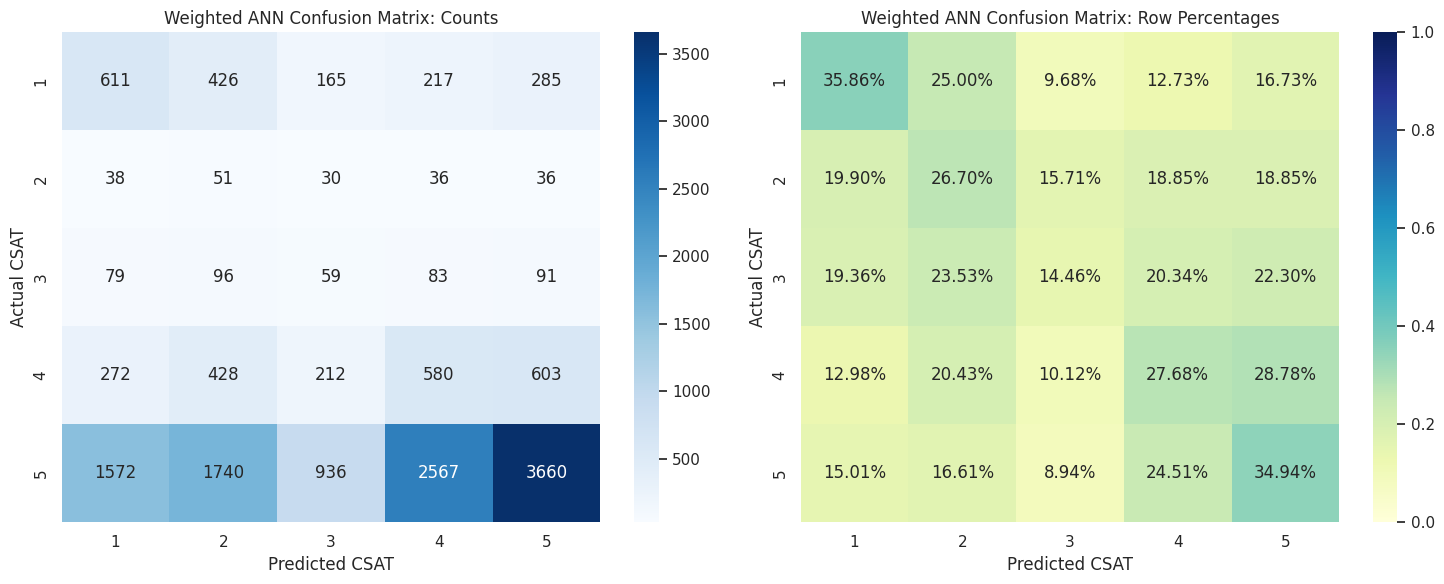

In [75]:
weighted_confusion_matrix = confusion_matrix(
    y_validation,
    validation_predicted_csat,
    labels=[1, 2, 3, 4, 5]
)

weighted_confusion_matrix_normalized = (
    weighted_confusion_matrix
    / weighted_confusion_matrix.sum(
        axis=1,
        keepdims=True
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.heatmap(
    weighted_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5],
    ax=axes[0]
)

axes[0].set_title(
    "Weighted ANN Confusion Matrix: Counts"
)
axes[0].set_xlabel("Predicted CSAT")
axes[0].set_ylabel("Actual CSAT")

sns.heatmap(
    weighted_confusion_matrix_normalized,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5],
    ax=axes[1]
)

axes[1].set_title(
    "Weighted ANN Confusion Matrix: Row Percentages"
)
axes[1].set_xlabel("Predicted CSAT")
axes[1].set_ylabel("Actual CSAT")

plt.tight_layout()
plt.show()

### Tuned ANN with Smoothed Class Weights

The first ANN used fully balanced class weights, which strongly penalized errors
on rare classes and produced relatively low validation accuracy. A second ANN
uses the square root of the balanced weights to create a more moderate trade-off
between majority-class accuracy and minority-class detection.

The tuned model also uses slightly lower dropout and a smaller learning rate for
more stable optimization.

In [76]:
smoothed_class_weights = {
    class_label: float(np.sqrt(class_weight))
    for class_label, class_weight
    in class_weight_dictionary.items()
}

smoothed_weight_table = pd.DataFrame({
    "ANN Class": list(smoothed_class_weights.keys()),
    "Original CSAT Score": [
        class_label + 1
        for class_label in smoothed_class_weights.keys()
    ],
    "Balanced Weight": [
        class_weight_dictionary[class_label]
        for class_label in smoothed_class_weights.keys()
    ],
    "Smoothed Weight": list(
        smoothed_class_weights.values()
    )
})

display(smoothed_weight_table.round(4))

tf.keras.backend.clear_session()

tuned_ann_model = keras.Sequential(
    [
        keras.Input(
            shape=(X_train_ann.shape[1],),
            name="processed_features"
        ),

        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001),
            name="dense_128"
        ),
        layers.BatchNormalization(
            name="batch_norm_128"
        ),
        layers.Dropout(
            0.25,
            name="dropout_25"
        ),

        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.0001),
            name="dense_64"
        ),
        layers.BatchNormalization(
            name="batch_norm_64"
        ),
        layers.Dropout(
            0.15,
            name="dropout_15"
        ),

        layers.Dense(
            32,
            activation="relu",
            name="dense_32"
        ),

        layers.Dense(
            5,
            activation="softmax",
            name="csat_probabilities"
        )
    ],
    name="DeepCSAT_Tuned_ANN"
)

tuned_ann_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tuned_ann_model.summary()

,ANN Class,Original CSAT Score,Balanced Weight,Smoothed Weight
0,0,1,1.4329,1.1971
1,1,2,12.7162,3.5660
2,2,3,6.4093,2.5317
3,3,4,1.5719,1.2538
4,4,5,0.2914,0.5398


Model: "DeepCSAT_Tuned_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_128                  │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_64                   │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ csat_probabilities (Dense)      │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,981 (121.02 KB)

 Trainable params: 30,597 (119.52 KB)

 Non-trainable params: 384 (1.50 KB)

### Training the Tuned ANN

The tuned ANN is trained with smoothed class weights, early stopping,
learning-rate reduction, and a separate model checkpoint. The validation set
is used to select the best epoch.

In [77]:
tuned_model_path = os.path.join(
    model_directory,
    "best_deepcsat_tuned_ann.keras"
)

tuned_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=tuned_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

tuned_history = tuned_ann_model.fit(
    X_train_ann,
    y_train_ann.to_numpy(),

    validation_data=(
        X_validation_ann,
        y_validation_ann.to_numpy()
    ),

    epochs=60,
    batch_size=256,

    class_weight=smoothed_class_weights,
    callbacks=tuned_callbacks,

    verbose=1
)

Epoch 1/60
226/233 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3255 - loss: 1.5053
Epoch 1: val_loss improved from None to 1.10787, saving model to /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_tuned_ann.keras

Epoch 1: finished saving model to /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_tuned_ann.keras
233/233 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.4832 - loss: 1.3260 - val_accuracy: 0.6743 - val_loss: 1.1079 - learning_rate: 5.0000e-04
Epoch 2/60
233/233 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6272 - loss: 1.1843
Epoch 2: val_loss improved from 1.10787 to 1.05508, saving model to /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_tuned_ann.keras

Epoch 2: finished saving model to /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_tuned_ann.

### Tuned ANN Validation Performance

The tuned model is evaluated using the same metrics as the majority baseline
and fully weighted ANN. Model selection will prioritize Macro-F1, quadratic
weighted kappa, MAE, and useful minority-class recall rather than accuracy
alone.

In [78]:
best_tuned_ann = keras.models.load_model(
    tuned_model_path
)

tuned_validation_loss, tuned_validation_accuracy = (
    best_tuned_ann.evaluate(
        X_validation_ann,
        y_validation_ann.to_numpy(),
        verbose=0
    )
)

tuned_validation_probabilities = (
    best_tuned_ann.predict(
        X_validation_ann,
        verbose=0
    )
)

tuned_validation_predictions = (
    np.argmax(
        tuned_validation_probabilities,
        axis=1
    ) + 1
)

tuned_ann_metrics = {
    "Accuracy": accuracy_score(
        y_validation,
        tuned_validation_predictions
    ),
    "Macro Precision": precision_score(
        y_validation,
        tuned_validation_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_validation,
        tuned_validation_predictions,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_validation,
        tuned_validation_predictions,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_validation,
        tuned_validation_predictions,
        average="weighted",
        zero_division=0
    ),
    "MAE": mean_absolute_error(
        y_validation,
        tuned_validation_predictions
    ),
    "Quadratic Weighted Kappa": cohen_kappa_score(
        y_validation,
        tuned_validation_predictions,
        weights="quadratic"
    )
}

validation_model_comparison = pd.DataFrame({
    "Majority Baseline": {
        **majority_baseline_metrics,
        "Weighted F1": f1_score(
            y_validation,
            majority_predictions,
            average="weighted",
            zero_division=0
        )
    },
    "Fully Weighted ANN": weighted_ann_metrics,
    "Tuned ANN": tuned_ann_metrics
}).reindex(metric_order)

print(
    f"Tuned validation loss: "
    f"{tuned_validation_loss:.4f}"
)
print(
    f"Tuned validation accuracy: "
    f"{tuned_validation_accuracy:.4f}"
)

print("\nValidation model comparison:")
display(validation_model_comparison.round(4))

print("\nTuned ANN classification report:\n")

print(
    classification_report(
        y_validation,
        tuned_validation_predictions,
        labels=[1, 2, 3, 4, 5],
        target_names=[
            "CSAT 1",
            "CSAT 2",
            "CSAT 3",
            "CSAT 4",
            "CSAT 5"
        ],
        zero_division=0,
        digits=4
    )
)

Tuned validation loss: 1.0472
Tuned validation accuracy: 0.6722

Validation model comparison:


,Majority Baseline,Fully Weighted ANN,Tuned ANN
Accuracy,0.7043,0.3336,0.6722
Macro Precision,0.1409,0.2495,0.2049
Macro Recall,0.2000,0.2793,0.2489
Macro F1,0.1653,0.2154,0.2247
Weighted F1,0.5821,0.4046,0.6047
MAE,0.6925,1.4622,0.8441
Quadratic Weighted Kappa,0.0000,0.1663,0.2259



Tuned ANN classification report:

              precision    recall  f1-score   support

      CSAT 1     0.2915    0.3462    0.3165      1704
      CSAT 2     0.0000    0.0000    0.0000       191
      CSAT 3     0.0000    0.0000    0.0000       408
      CSAT 4     0.0000    0.0000    0.0000      2095
      CSAT 5     0.7330    0.8980    0.8072     10475

    accuracy                         0.6722     14873
   macro avg     0.2049    0.2489    0.2247     14873
weighted avg     0.5496    0.6722    0.6047     14873



### Final ANN Selection Using Validation Performance

The final ANN is selected using validation metrics only. Macro-F1 is the primary
selection metric because it gives equal importance to all five CSAT classes.
Quadratic weighted kappa is used as the first tie-breaker, followed by MAE.

The test set is not used during model selection.

In [79]:
ann_selection_table = pd.DataFrame({
    "Fully Weighted ANN": weighted_ann_metrics,
    "Tuned ANN": tuned_ann_metrics
}).T

ann_selection_table["Model"] = (
    ann_selection_table.index
)

ann_selection_ranking = (
    ann_selection_table
    .sort_values(
        by=[
            "Macro F1",
            "Quadratic Weighted Kappa",
            "MAE"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
)

selected_model_name = (
    ann_selection_ranking.index[0]
)

if selected_model_name == "Fully Weighted ANN":
    selected_ann_model = best_weighted_ann
    selected_model_path = best_model_path
else:
    selected_ann_model = best_tuned_ann
    selected_model_path = tuned_model_path

print("ANN selection ranking:")
display(
    ann_selection_ranking[
        [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1",
            "Weighted F1",
            "MAE",
            "Quadratic Weighted Kappa"
        ]
    ].round(4)
)

print("Selected final ANN:", selected_model_name)
print("Selected model path:", selected_model_path)

ANN selection ranking:


,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,MAE,Quadratic Weighted Kappa
Tuned ANN,0.6722,0.2049,0.2489,0.2247,0.6047,0.8441,0.2259
Fully Weighted ANN,0.3336,0.2495,0.2793,0.2154,0.4046,1.4622,0.1663


Selected final ANN: Tuned ANN
Selected model path: /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/best_deepcsat_tuned_ann.keras


### Final Evaluation on the Untouched Test Set

After model selection, the chosen ANN is evaluated once on the latest,
previously unseen test period. This provides the final estimate of how the model
may perform on future customer-support interactions.

In [80]:
test_loss, test_accuracy = (
    selected_ann_model.evaluate(
        X_test_ann,
        y_test_ann.to_numpy(),
        verbose=0
    )
)

test_probabilities = (
    selected_ann_model.predict(
        X_test_ann,
        verbose=0
    )
)

test_predicted_ann_classes = np.argmax(
    test_probabilities,
    axis=1
)

test_predicted_csat = (
    test_predicted_ann_classes + 1
)

final_test_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        test_predicted_csat
    ),
    "Macro Precision": precision_score(
        y_test,
        test_predicted_csat,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_test,
        test_predicted_csat,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_test,
        test_predicted_csat,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test,
        test_predicted_csat,
        average="weighted",
        zero_division=0
    ),
    "MAE": mean_absolute_error(
        y_test,
        test_predicted_csat
    ),
    "Quadratic Weighted Kappa": cohen_kappa_score(
        y_test,
        test_predicted_csat,
        weights="quadratic"
    )
}

selected_validation_metrics = (
    weighted_ann_metrics
    if selected_model_name == "Fully Weighted ANN"
    else tuned_ann_metrics
)

final_performance_table = pd.DataFrame({
    "Selected Model Validation": selected_validation_metrics,
    "Selected Model Test": final_test_metrics
}).reindex(metric_order)

print("Final selected model:", selected_model_name)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(
    "Test probability array shape:",
    test_probabilities.shape
)
print(
    "Predicted test CSAT scores:",
    sorted(np.unique(test_predicted_csat))
)

print("\nFinal performance:")
display(final_performance_table.round(4))

print("\nFinal test classification report:\n")

print(
    classification_report(
        y_test,
        test_predicted_csat,
        labels=[1, 2, 3, 4, 5],
        target_names=[
            "CSAT 1",
            "CSAT 2",
            "CSAT 3",
            "CSAT 4",
            "CSAT 5"
        ],
        zero_division=0,
        digits=4
    )
)

Final selected model: Tuned ANN
Test loss: 1.0278
Test accuracy: 0.6886
Test probability array shape: (11395, 5)
Predicted test CSAT scores: [np.int64(1), np.int64(3), np.int64(4), np.int64(5)]

Final performance:


,Selected Model Validation,Selected Model Test
Accuracy,0.6722,0.6886
Macro Precision,0.2049,0.2355
Macro Recall,0.2489,0.2393
Macro F1,0.2247,0.2193
Weighted F1,0.6047,0.6195
MAE,0.8441,0.7940
Quadratic Weighted Kappa,0.2259,0.1883



Final test classification report:

              precision    recall  f1-score   support

      CSAT 1     0.2693    0.2812    0.2751      1202
      CSAT 2     0.0000    0.0000    0.0000       154
      CSAT 3     0.0000    0.0000    0.0000       289
      CSAT 4     0.1667    0.0013    0.0026      1536
      CSAT 5     0.7413    0.9139    0.8186      8214

    accuracy                         0.6886     11395
   macro avg     0.2355    0.2393    0.2193     11395
weighted avg     0.5852    0.6886    0.6195     11395



### Final Test Confusion Matrix

The final confusion matrix shows how the selected ANN performs on the untouched
test period. The row-normalized matrix is used to compare recall across classes
with very different sample sizes.

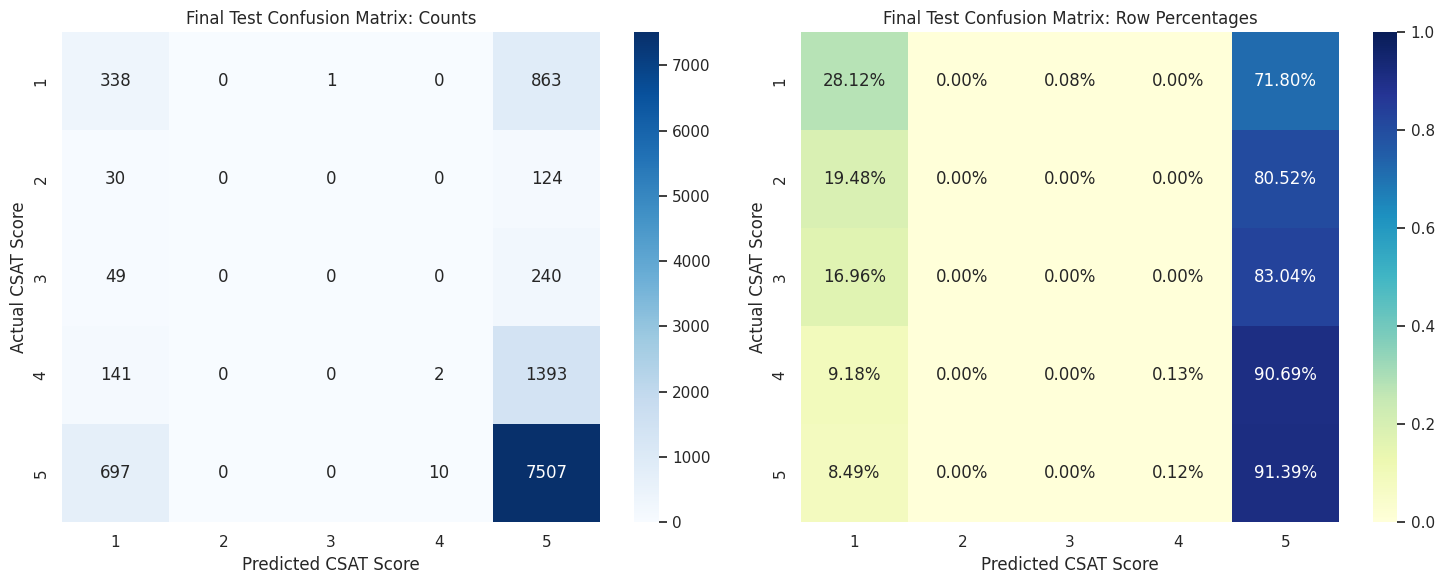

In [81]:
final_test_confusion_matrix = confusion_matrix(
    y_test,
    test_predicted_csat,
    labels=[1, 2, 3, 4, 5]
)

final_test_confusion_normalized = (
    final_test_confusion_matrix
    / final_test_confusion_matrix.sum(
        axis=1,
        keepdims=True
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.heatmap(
    final_test_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5],
    ax=axes[0]
)

axes[0].set_title(
    "Final Test Confusion Matrix: Counts"
)
axes[0].set_xlabel("Predicted CSAT Score")
axes[0].set_ylabel("Actual CSAT Score")

sns.heatmap(
    final_test_confusion_normalized,
    annot=True,
    fmt=".2%",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    xticklabels=[1, 2, 3, 4, 5],
    yticklabels=[1, 2, 3, 4, 5],
    ax=axes[1]
)

axes[1].set_title(
    "Final Test Confusion Matrix: Row Percentages"
)
axes[1].set_xlabel("Predicted CSAT Score")
axes[1].set_ylabel("Actual CSAT Score")

plt.tight_layout()
plt.show()

### Model Interpretability Using Grouped Permutation Importance

Grouped permutation importance measures how much validation Macro-F1 decreases
when one original feature is randomly shuffled. A larger performance decrease
indicates that the selected ANN depends more strongly on that feature.

The analysis is performed on a reproducible validation sample to control
computation time. The test set remains untouched by the interpretability
process.

In [82]:
PERMUTATION_SAMPLE_SIZE = min(
    5000,
    len(X_validation)
)

permutation_random_generator = np.random.default_rng(
    RANDOM_STATE
)

permutation_positions = (
    permutation_random_generator.choice(
        len(X_validation),
        size=PERMUTATION_SAMPLE_SIZE,
        replace=False
    )
)

X_permutation_sample = (
    X_validation.iloc[
        permutation_positions
    ].copy()
)

y_permutation_sample = (
    y_validation.iloc[
        permutation_positions
    ].copy()
)


def prepare_model_array(raw_data):
    frequency_encoded_data = apply_frequency_encoding(
        raw_data,
        frequency_maps
    )

    compatible_data = convert_categorical_missing_values(
        frequency_encoded_data
    )

    processed_data = preprocessor.transform(
        compatible_data
    )

    return processed_data.astype(np.float32)


baseline_permutation_array = prepare_model_array(
    X_permutation_sample
)

baseline_permutation_predictions = (
    np.argmax(
        selected_ann_model.predict(
            baseline_permutation_array,
            verbose=0
        ),
        axis=1
    ) + 1
)

baseline_permutation_macro_f1 = f1_score(
    y_permutation_sample,
    baseline_permutation_predictions,
    average="macro",
    zero_division=0
)

permutation_results = []

for feature_number, feature_name in enumerate(
    model_features,
    start=1
):
    shuffled_data = X_permutation_sample.copy()

    shuffled_data[feature_name] = (
        permutation_random_generator.permutation(
            shuffled_data[feature_name].to_numpy()
        )
    )

    shuffled_array = prepare_model_array(
        shuffled_data
    )

    shuffled_predictions = (
        np.argmax(
            selected_ann_model.predict(
                shuffled_array,
                verbose=0
            ),
            axis=1
        ) + 1
    )

    shuffled_macro_f1 = f1_score(
        y_permutation_sample,
        shuffled_predictions,
        average="macro",
        zero_division=0
    )

    permutation_results.append({
        "Feature": feature_name,
        "Baseline Macro F1": baseline_permutation_macro_f1,
        "Shuffled Macro F1": shuffled_macro_f1,
        "Importance": (
            baseline_permutation_macro_f1
            - shuffled_macro_f1
        )
    })

    print(
        f"Completed {feature_number:02d}/"
        f"{len(model_features)}: {feature_name}"
    )

permutation_importance_table = (
    pd.DataFrame(permutation_results)
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "\nValidation sample size:",
    PERMUTATION_SAMPLE_SIZE
)
print(
    "Baseline sample Macro-F1:",
    round(baseline_permutation_macro_f1, 4)
)

Completed 01/24: log_item_price
Completed 02/24: log_response_time_minutes
Completed 03/24: log_order_to_issue_hours
Completed 04/24: issue_hour
Completed 05/24: issue_day_number
Completed 06/24: is_weekend
Completed 07/24: invalid_response_time
Completed 08/24: invalid_order_to_issue_time
Completed 09/24: is_order_id_missing
Completed 10/24: is_order_date_time_missing
Completed 11/24: is_customer_remarks_missing
Completed 12/24: is_customer_city_missing
Completed 13/24: is_product_category_missing
Completed 14/24: is_item_price_missing
Completed 15/24: channel_name
Completed 16/24: category
Completed 17/24: sub_category
Completed 18/24: product_category
Completed 19/24: supervisor
Completed 20/24: manager
Completed 21/24: tenure_bucket
Completed 22/24: agent_shift
Completed 23/24: customer_city
Completed 24/24: agent_name

Validation sample size: 5000
Baseline sample Macro-F1: 0.2241


### Most Influential Model Features

The fifteen features causing the largest decrease in validation Macro-F1 are
visualized. Negative importance means that shuffling a feature slightly
improved the sampled score, suggesting limited usefulness or sampling noise.
Permutation importance describes predictive dependence and does not prove
causation.

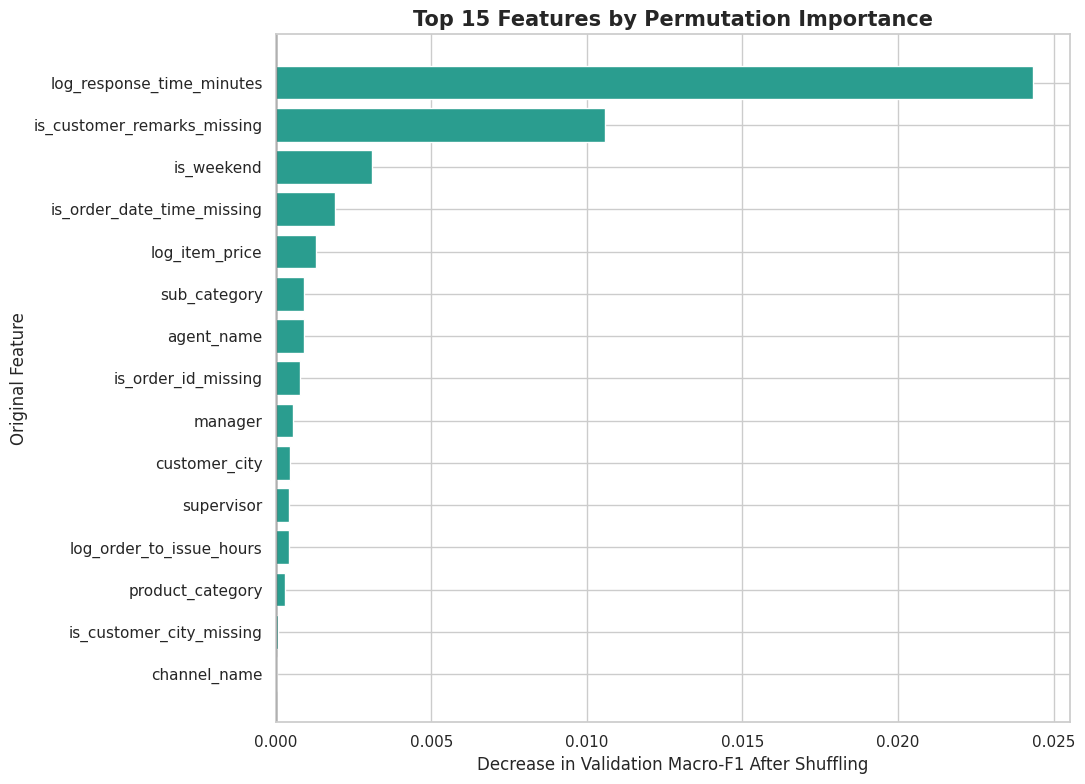

,Feature,Baseline Macro F1,Shuffled Macro F1,Importance
0,log_response_time_minutes,0.2241,0.1998,0.0243
1,is_customer_remarks_missing,0.2241,0.2136,0.0106
2,is_weekend,0.2241,0.2210,0.0031
3,is_order_date_time_missing,0.2241,0.2222,0.0019
4,log_item_price,0.2241,0.2228,0.0013
5,sub_category,0.2241,0.2232,0.0009
6,agent_name,0.2241,0.2232,0.0009
7,is_order_id_missing,0.2241,0.2234,0.0008
8,manager,0.2241,0.2236,0.0005
9,customer_city,0.2241,0.2237,0.0004


In [83]:
top_feature_importance = (
    permutation_importance_table
    .head(15)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(figsize=(11, 8))

importance_colors = [
    "#2A9D8F" if value >= 0 else "#E76F51"
    for value in top_feature_importance["Importance"]
]

plt.barh(
    top_feature_importance["Feature"],
    top_feature_importance["Importance"],
    color=importance_colors
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Top 15 Features by Permutation Importance",
    fontsize=15,
    fontweight="bold"
)
plt.xlabel(
    "Decrease in Validation Macro-F1 After Shuffling"
)
plt.ylabel("Original Feature")
plt.tight_layout()
plt.show()

display(
    permutation_importance_table[
        [
            "Feature",
            "Baseline Macro F1",
            "Shuffled Macro F1",
            "Importance"
        ]
    ].round(4)
)

### Saving the Final Model and Preprocessing Artifacts

The selected ANN, fitted preprocessing pipeline, training-frequency mappings,
and model metadata are saved together. Deployment requires the exact same
transformations used during training.

In [84]:
import json

final_model_path = os.path.join(
    model_directory,
    "deepcsat_final_model.keras"
)

preprocessor_path = os.path.join(
    model_directory,
    "deepcsat_preprocessor.joblib"
)

frequency_maps_path = os.path.join(
    model_directory,
    "deepcsat_frequency_maps.joblib"
)

metadata_path = os.path.join(
    model_directory,
    "deepcsat_metadata.json"
)

selected_ann_model.save(
    final_model_path
)

joblib.dump(
    preprocessor,
    preprocessor_path
)

joblib.dump(
    frequency_maps,
    frequency_maps_path
)

model_metadata = {
    "project_name": (
        "DeepCSAT: E-Commerce Customer "
        "Satisfaction Score Prediction"
    ),
    "selected_model": selected_model_name,
    "target_name": "csat_score",
    "target_mapping": {
        "0": 1,
        "1": 2,
        "2": 3,
        "3": 4,
        "4": 5
    },
    "model_features": model_features,
    "numeric_features_after_frequency_encoding": (
        encoded_numeric_features
    ),
    "low_cardinality_features": (
        low_cardinality_features
    ),
    "high_cardinality_features": (
        high_cardinality_features
    ),
    "processed_feature_count": int(
        X_train_ann.shape[1]
    ),
    "test_metrics": {
        metric: float(value)
        for metric, value
        in final_test_metrics.items()
    }
}

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as metadata_file:
    json.dump(
        model_metadata,
        metadata_file,
        indent=4
    )

saved_artifacts = {
    "Final ANN model": final_model_path,
    "Preprocessor": preprocessor_path,
    "Frequency maps": frequency_maps_path,
    "Model metadata": metadata_path
}

print("Artifacts saved successfully:\n")

for artifact_name, artifact_path in saved_artifacts.items():
    print(
        f"{artifact_name}: "
        f"{os.path.exists(artifact_path)}"
    )
    print(artifact_path)

Artifacts saved successfully:

Final ANN model: True
/content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/deepcsat_final_model.keras
Preprocessor: True
/content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/deepcsat_preprocessor.joblib
Frequency maps: True
/content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/deepcsat_frequency_maps.joblib
Model metadata: True
/content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/models/deepcsat_metadata.json


### Reloading and Verifying Saved Artifacts

The saved ANN, preprocessing pipeline, frequency mappings, and metadata are
reloaded from Google Drive. Their predictions are compared with the predictions
generated before saving to verify deployment consistency.

In [85]:
reloaded_model = keras.models.load_model(
    final_model_path
)

reloaded_preprocessor = joblib.load(
    preprocessor_path
)

reloaded_frequency_maps = joblib.load(
    frequency_maps_path
)

with open(
    metadata_path,
    "r",
    encoding="utf-8"
) as metadata_file:
    reloaded_metadata = json.load(
        metadata_file
    )


def apply_loaded_frequency_encoding(
    data,
    loaded_mappings
):
    encoded_data = data.copy()

    for column, frequency_map in loaded_mappings.items():
        prepared_values = (
            encoded_data[column]
            .fillna("__MISSING__")
        )

        encoded_data[f"{column}_frequency"] = (
            prepared_values
            .map(frequency_map)
            .fillna(0.0)
            .astype(float)
        )

    return encoded_data.drop(
        columns=high_cardinality_features
    )


reload_test_sample = X_test.iloc[:100].copy()

reload_frequency_data = (
    apply_loaded_frequency_encoding(
        reload_test_sample,
        reloaded_frequency_maps
    )
)

reload_compatible_data = (
    convert_categorical_missing_values(
        reload_frequency_data
    )
)

reload_processed_sample = (
    reloaded_preprocessor
    .transform(reload_compatible_data)
    .astype(np.float32)
)

reload_probabilities = reloaded_model.predict(
    reload_processed_sample,
    verbose=0
)

original_sample_probabilities = (
    test_probabilities[:100]
)

maximum_probability_difference = np.max(
    np.abs(
        reload_probabilities
        - original_sample_probabilities
    )
)

original_sample_predictions = np.argmax(
    original_sample_probabilities,
    axis=1
)

reloaded_sample_predictions = np.argmax(
    reload_probabilities,
    axis=1
)

print(
    "Reloaded project name:",
    reloaded_metadata["project_name"]
)
print(
    "Reloaded selected model:",
    reloaded_metadata["selected_model"]
)
print(
    "Reloaded processed feature count:",
    reloaded_metadata["processed_feature_count"]
)
print(
    "Reloaded sample shape:",
    reload_processed_sample.shape
)
print(
    "Maximum probability difference:",
    maximum_probability_difference
)
print(
    "Class predictions identical:",
    np.array_equal(
        original_sample_predictions,
        reloaded_sample_predictions
    )
)

Reloaded project name: DeepCSAT: E-Commerce Customer Satisfaction Score Prediction
Reloaded selected model: Tuned ANN
Reloaded processed feature count: 153
Reloaded sample shape: (100, 153)
Maximum probability difference: 5.9604645e-08
Class predictions identical: True


### Creating a Business-Friendly Test Prediction Table

The test predictions are combined with record identifiers, timestamps,
prediction probabilities, and prediction errors. The probability of low
satisfaction is defined as the combined probability of CSAT scores 1 and 2.

In [86]:
test_prediction_results = pd.DataFrame({
    "unique_id": (
        df_clean.loc[
            test_data.index,
            "unique_id"
        ].to_numpy()
    ),
    "issue_reported_at": (
        test_data[
            "issue_reported_at"
        ].to_numpy()
    ),
    "actual_csat": (
        y_test.to_numpy()
    ),
    "predicted_csat": (
        test_predicted_csat
    ),
    "prediction_probability": (
        test_probabilities.max(axis=1)
    ),
    "low_csat_probability": (
        test_probabilities[:, 0]
        + test_probabilities[:, 1]
    )
})

test_prediction_results["absolute_error"] = (
    test_prediction_results["actual_csat"]
    - test_prediction_results["predicted_csat"]
).abs()

test_prediction_results["correct_prediction"] = (
    test_prediction_results["actual_csat"]
    == test_prediction_results["predicted_csat"]
)

print(
    "Prediction table shape:",
    test_prediction_results.shape
)
print(
    "Correctly predicted records:",
    test_prediction_results[
        "correct_prediction"
    ].sum()
)
print(
    "Mean prediction probability:",
    round(
        test_prediction_results[
            "prediction_probability"
        ].mean(),
        4
    )
)
print(
    "Mean low-CSAT probability:",
    round(
        test_prediction_results[
            "low_csat_probability"
        ].mean(),
        4
    )
)

test_prediction_results.head(10)

Prediction table shape: (11395, 8)
Correctly predicted records: 7847
Mean prediction probability: 0.495
Mean low-CSAT probability: 0.2367


,unique_id,issue_reported_at,actual_csat,predicted_csat,prediction_probability,low_csat_probability,absolute_error,correct_prediction
0,ce2ad1e7-0caa-485a-9956-3684684d5d37,2023-08-28 00:25:00,4,5,0.523888,0.201480,1,False
1,93a5e1bc-8e2c-4964-be5a-a32602aa7b81,2023-08-28 00:55:00,5,5,0.379365,0.280994,0,True
2,04b96085-986c-4882-a246-cbe804666642,2023-08-28 00:34:00,5,5,0.696846,0.045436,0,True
3,f1a0a678-0abe-4e90-86b6-fae13cc256fa,2023-08-28 00:28:00,5,5,0.664657,0.145550,0,True
4,df2e7b97-1323-4e33-a86d-ecdcf029513f,2023-08-28 00:57:00,5,5,0.413005,0.218522,0,True
5,beaf33c1-337f-40c7-9ac9-50fed087d16c,2023-08-28 00:43:00,5,5,0.487960,0.168949,0,True
6,d623baab-f6a1-4684-ae40-e40f94300245,2023-08-28 00:44:00,5,5,0.663747,0.096113,0,True
7,9ddc436a-566e-45e3-9279-026af49cd3cc,2023-08-28 00:48:00,5,5,0.461114,0.236199,0,True
8,05b55dfd-bf24-4cf0-b944-189ffe6512f3,2023-08-28 00:12:00,5,5,0.718417,0.095090,0,True
9,23e1c383-3b6f-4e63-ad3e-95b43915aa73,2023-08-28 00:31:00,5,5,0.674276,0.072919,0,True


### Saving Test Predictions for Business Review

The final test predictions are saved as a CSV report. The file can be used for
error analysis, business review, and demonstration during the local deployment
presentation.

In [87]:
reports_directory = (
    "/content/drive/MyDrive/"
    "DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/"
    "reports"
)

os.makedirs(
    reports_directory,
    exist_ok=True
)

test_predictions_path = os.path.join(
    reports_directory,
    "deepcsat_test_predictions.csv"
)

test_prediction_results.to_csv(
    test_predictions_path,
    index=False
)

absolute_error_summary = (
    test_prediction_results[
        "absolute_error"
    ]
    .value_counts()
    .sort_index()
    .rename("Record Count")
    .to_frame()
)

absolute_error_summary["Percentage"] = (
    absolute_error_summary["Record Count"]
    / len(test_prediction_results)
    * 100
).round(2)

print(
    "Prediction report saved:",
    os.path.exists(test_predictions_path)
)
print(
    "Prediction report path:",
    test_predictions_path
)
print(
    "Saved report rows:",
    len(test_prediction_results)
)

print("\nAbsolute-error distribution:")
display(absolute_error_summary)

Prediction report saved: True
Prediction report path: /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/reports/deepcsat_test_predictions.csv
Saved report rows: 11395

Absolute-error distribution:


,Record Count,Percentage
absolute_error,,
0,7847,68.86
1,1433,12.58
2,290,2.54
3,265,2.33
4,1560,13.69


## Local Deployment

### Creating the Streamlit Prediction Application

A local Streamlit application is created to accept customer-support interaction
details, reproduce the saved preprocessing workflow, generate CSAT
probabilities, and display the predicted satisfaction score.

In [88]:
app_directory = (
    "/content/drive/MyDrive/"
    "DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/"
    "app"
)

os.makedirs(
    app_directory,
    exist_ok=True
)

streamlit_app_path = os.path.join(
    app_directory,
    "app.py"
)

streamlit_app_code = r'''
from pathlib import Path
from datetime import datetime
import json

import joblib
import numpy as np
import pandas as pd
import streamlit as st
import tensorflow as tf


st.set_page_config(
    page_title="DeepCSAT",
    page_icon="⭐",
    layout="wide"
)


PROJECT_ROOT = Path(__file__).resolve().parent.parent
MODEL_DIRECTORY = PROJECT_ROOT / "models"

MODEL_PATH = MODEL_DIRECTORY / "deepcsat_final_model.keras"
PREPROCESSOR_PATH = MODEL_DIRECTORY / "deepcsat_preprocessor.joblib"
FREQUENCY_MAPS_PATH = MODEL_DIRECTORY / "deepcsat_frequency_maps.joblib"
METADATA_PATH = MODEL_DIRECTORY / "deepcsat_metadata.json"


@st.cache_resource
def load_artifacts():
    model = tf.keras.models.load_model(MODEL_PATH)
    preprocessor = joblib.load(PREPROCESSOR_PATH)
    frequency_maps = joblib.load(FREQUENCY_MAPS_PATH)

    with open(
        METADATA_PATH,
        "r",
        encoding="utf-8"
    ) as metadata_file:
        metadata = json.load(metadata_file)

    return model, preprocessor, frequency_maps, metadata


def get_category_options(preprocessor, feature_names):
    categorical_pipeline = (
        preprocessor.named_transformers_["categorical"]
    )

    onehot_encoder = (
        categorical_pipeline.named_steps["onehot"]
    )

    return {
        feature: [
            str(value)
            for value in categories
        ]
        for feature, categories in zip(
            feature_names,
            onehot_encoder.categories_
        )
    }


def apply_frequency_encoding(
    data,
    frequency_maps,
    high_cardinality_features
):
    encoded_data = data.copy()

    for column, frequency_map in frequency_maps.items():
        prepared_values = (
            encoded_data[column]
            .fillna("__MISSING__")
        )

        encoded_data[f"{column}_frequency"] = (
            prepared_values
            .map(frequency_map)
            .fillna(0.0)
            .astype(float)
        )

    return encoded_data.drop(
        columns=high_cardinality_features
    )


def prepare_input(
    raw_input,
    preprocessor,
    frequency_maps,
    metadata
):
    input_data = pd.DataFrame([raw_input])

    encoded_data = apply_frequency_encoding(
        input_data,
        frequency_maps,
        metadata["high_cardinality_features"]
    )

    for column in metadata["low_cardinality_features"]:
        encoded_data[column] = (
            encoded_data[column]
            .astype(object)
            .where(
                encoded_data[column].notna(),
                np.nan
            )
        )

    processed_data = preprocessor.transform(
        encoded_data
    )

    return processed_data.astype(np.float32)


try:
    model, preprocessor, frequency_maps, metadata = (
        load_artifacts()
    )
except Exception as error:
    st.error(
        "The saved model artifacts could not be loaded. "
        "Confirm that the models folder is beside the app folder."
    )
    st.exception(error)
    st.stop()


category_options = get_category_options(
    preprocessor,
    metadata["low_cardinality_features"]
)


st.title(
    "DeepCSAT: E-Commerce Customer Satisfaction Score Prediction"
)

st.write(
    "Enter the available customer-support interaction details. "
    "The application will estimate the probability of each CSAT score."
)

st.caption(
    "Prediction point: after the support response and before the "
    "customer submits the satisfaction survey."
)


with st.form("deepcsat_prediction_form"):
    left_column, right_column = st.columns(2)

    with left_column:
        channel_name = st.selectbox(
            "Support channel",
            category_options["channel_name"]
        )

        category = st.selectbox(
            "Interaction category",
            category_options["category"]
        )

        sub_category = st.selectbox(
            "Interaction sub-category",
            category_options["sub_category"]
        )

        tenure_bucket = st.selectbox(
            "Agent tenure bucket",
            category_options["tenure_bucket"]
        )

        agent_shift = st.selectbox(
            "Agent shift",
            category_options["agent_shift"]
        )

        supervisor = st.selectbox(
            "Supervisor",
            category_options["supervisor"]
        )

        manager = st.selectbox(
            "Manager",
            category_options["manager"]
        )

    with right_column:
        product_options = (
            ["<Missing>"]
            + category_options["product_category"]
        )

        selected_product_category = st.selectbox(
            "Product category",
            product_options
        )

        customer_city = st.text_input(
            "Customer city",
            placeholder="Leave blank if unavailable"
        )

        agent_name = st.text_input(
            "Agent name",
            placeholder="Enter the agent name"
        )

        issue_date = st.date_input(
            "Issue-reported date"
        )

        issue_time = st.time_input(
            "Issue-reported time"
        )

        response_time_minutes = st.number_input(
            "Response time in minutes",
            min_value=0.0,
            value=5.0,
            step=1.0
        )

    st.subheader("Optional order information")

    option_column_1, option_column_2 = st.columns(2)

    with option_column_1:
        order_id_available = st.checkbox(
            "Order ID is available",
            value=True
        )

        order_date_available = st.checkbox(
            "Order date is available",
            value=False
        )

        remarks_available = st.checkbox(
            "Customer remarks are available",
            value=False
        )

    with option_column_2:
        item_price_available = st.checkbox(
            "Item price is available",
            value=False
        )

        if item_price_available:
            item_price = st.number_input(
                "Item price",
                min_value=0.0,
                value=1000.0,
                step=100.0
            )
        else:
            item_price = np.nan

        if order_date_available:
            order_to_issue_hours = st.number_input(
                "Hours between order and issue",
                min_value=0.0,
                value=24.0,
                step=1.0
            )
        else:
            order_to_issue_hours = np.nan

    submit_prediction = st.form_submit_button(
        "Predict CSAT Score",
        use_container_width=True
    )


if submit_prediction:
    issue_timestamp = datetime.combine(
        issue_date,
        issue_time
    )

    product_category = (
        np.nan
        if selected_product_category == "<Missing>"
        else selected_product_category
    )

    cleaned_city = (
        customer_city.strip()
        if customer_city.strip()
        else np.nan
    )

    cleaned_agent = (
        agent_name.strip()
        if agent_name.strip()
        else np.nan
    )

    raw_model_input = {
        "log_item_price": (
            np.log1p(item_price)
            if item_price_available
            else np.nan
        ),
        "log_response_time_minutes": np.log1p(
            response_time_minutes
        ),
        "log_order_to_issue_hours": (
            np.log1p(order_to_issue_hours)
            if order_date_available
            else np.nan
        ),
        "issue_hour": issue_timestamp.hour,
        "issue_day_number": issue_timestamp.weekday(),
        "is_weekend": int(
            issue_timestamp.weekday() in [5, 6]
        ),
        "invalid_response_time": 0,
        "invalid_order_to_issue_time": 0,
        "is_order_id_missing": int(
            not order_id_available
        ),
        "is_order_date_time_missing": int(
            not order_date_available
        ),
        "is_customer_remarks_missing": int(
            not remarks_available
        ),
        "is_customer_city_missing": int(
            pd.isna(cleaned_city)
        ),
        "is_product_category_missing": int(
            pd.isna(product_category)
        ),
        "is_item_price_missing": int(
            not item_price_available
        ),
        "channel_name": channel_name,
        "category": category,
        "sub_category": sub_category,
        "product_category": product_category,
        "supervisor": supervisor,
        "manager": manager,
        "tenure_bucket": tenure_bucket,
        "agent_shift": agent_shift,
        "customer_city": cleaned_city,
        "agent_name": cleaned_agent
    }

    processed_input = prepare_input(
        raw_model_input,
        preprocessor,
        frequency_maps,
        metadata
    )

    probabilities = model.predict(
        processed_input,
        verbose=0
    )[0]

    predicted_csat = int(
        np.argmax(probabilities) + 1
    )

    low_csat_probability = float(
        probabilities[0] + probabilities[1]
    )

    result_column_1, result_column_2 = st.columns(2)

    with result_column_1:
        st.metric(
            "Predicted CSAT Score",
            f"{predicted_csat} / 5"
        )

    with result_column_2:
        st.metric(
            "Probability of Low CSAT (1 or 2)",
            f"{low_csat_probability:.1%}"
        )

    probability_table = pd.DataFrame({
        "CSAT Score": [1, 2, 3, 4, 5],
        "Model Probability": probabilities
    }).set_index("CSAT Score")

    st.subheader("Predicted Score Probabilities")
    st.bar_chart(probability_table)

    st.dataframe(
        probability_table.style.format({
            "Model Probability": "{:.2%}"
        }),
        use_container_width=True
    )

    if low_csat_probability >= 0.50:
        st.warning(
            "High predicted risk of low satisfaction. "
            "Consider proactive review or follow-up."
        )
    elif low_csat_probability >= 0.25:
        st.info(
            "Moderate predicted risk of low satisfaction. "
            "Monitor the interaction outcome."
        )
    else:
        st.success(
            "The model estimates a relatively low risk "
            "of CSAT scores 1 or 2."
        )

    st.caption(
        "Model probabilities are predictive outputs and should not be "
        "interpreted as verified confidence unless probability calibration "
        "has been evaluated."
    )
'''

with open(
    streamlit_app_path,
    "w",
    encoding="utf-8"
) as app_file:
    app_file.write(streamlit_app_code)

print(
    "Streamlit app created:",
    os.path.exists(streamlit_app_path)
)
print("App path:", streamlit_app_path)

Streamlit app created: True
App path: /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/app/app.py


### Creating the Deployment Requirements File

The requirements file lists the Python packages needed to run the application
on a local system.

In [89]:
requirements_path = os.path.join(
    app_directory,
    "requirements.txt"
)

requirements_content = """streamlit
tensorflow
pandas
numpy
scikit-learn
joblib
"""

with open(
    requirements_path,
    "w",
    encoding="utf-8"
) as requirements_file:
    requirements_file.write(
        requirements_content
    )

print(
    "Requirements file created:",
    os.path.exists(requirements_path)
)
print(
    "Requirements path:",
    requirements_path
)

print("\nRequirements:\n")
print(requirements_content)

Requirements file created: True
Requirements path: /content/drive/MyDrive/DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/app/requirements.txt

Requirements:

streamlit
tensorflow
pandas
numpy
scikit-learn
joblib



### Creating Local Deployment Instructions

A README file is created with the commands required to install the project
dependencies and launch the Streamlit application locally.

In [90]:
deployment_readme_path = os.path.join(
    app_directory,
    "LOCAL_DEPLOYMENT.md"
)

deployment_readme_content = """# DeepCSAT Local Deployment

## Required project structure

DeepCSAT - E-Commerce Customer Satisfaction Score Prediction/
├── app/
│   ├── app.py
│   ├── requirements.txt
│   └── LOCAL_DEPLOYMENT.md
└── models/
    ├── deepcsat_final_model.keras
    ├── deepcsat_preprocessor.joblib
    ├── deepcsat_frequency_maps.joblib
    └── deepcsat_metadata.json

## Windows setup

Open PowerShell inside the main project folder.

Create a virtual environment:

    python -m venv .venv

Activate the environment:

    .venv\\Scripts\\Activate.ps1

Install dependencies:

    pip install -r app\\requirements.txt

Run the application:

    streamlit run app\\app.py

Streamlit will display a local URL, normally:

    http://localhost:8501

Open that URL in a browser to use the application.
"""

with open(
    deployment_readme_path,
    "w",
    encoding="utf-8"
) as readme_file:
    readme_file.write(
        deployment_readme_content
    )

deployment_files = {
    "Streamlit application": streamlit_app_path,
    "Requirements file": requirements_path,
    "Deployment instructions": deployment_readme_path,
    "Final ANN model": final_model_path,
    "Preprocessor": preprocessor_path,
    "Frequency maps": frequency_maps_path,
    "Metadata": metadata_path
}

deployment_check = pd.DataFrame({
    "File": deployment_files.keys(),
    "Exists": [
        os.path.exists(path)
        for path in deployment_files.values()
    ],
    "Path": deployment_files.values()
})

display(deployment_check)

print(
    "All deployment files available:",
    deployment_check["Exists"].all()
)

,File,Exists,Path
0,Streamlit application,True,/content/drive/MyDrive/DeepCSAT - E-Commerce C...
1,Requirements file,True,/content/drive/MyDrive/DeepCSAT - E-Commerce C...
2,Deployment instructions,True,/content/drive/MyDrive/DeepCSAT - E-Commerce C...
3,Final ANN model,True,/content/drive/MyDrive/DeepCSAT - E-Commerce C...
4,Preprocessor,True,/content/drive/MyDrive/DeepCSAT - E-Commerce C...
5,Frequency maps,True,/content/drive/MyDrive/DeepCSAT - E-Commerce C...
6,Metadata,True,/content/drive/MyDrive/DeepCSAT - E-Commerce C...


All deployment files available: True


# Project Summary and Repository

## Project Summary

DeepCSAT is an end-to-end deep learning solution developed to predict customer satisfaction scores from e-commerce customer-support interactions. The project includes data-integrity validation, exploratory data analysis, feature engineering, chronological validation, ANN development, class-imbalance handling, model interpretation and local deployment.

The final Tuned ANN processes 153 engineered features and predicts the probability of CSAT scores from 1 to 5. On the chronological test set, the model achieved an accuracy of 68.86%, Weighted F1 of 61.95%, Macro F1 of 21.93%, Mean Absolute Error of 0.7940 and Quadratic Weighted Kappa of 0.1883.

The results show that severe class imbalance affects the prediction of minority CSAT classes. Therefore, the application presents class probabilities and low-CSAT risk to support operational decisions instead of relying only on the predicted class.

## Local Deployment

The trained model, preprocessing pipeline, frequency maps and metadata were integrated into a Streamlit application. The application accepts customer-support interaction details and returns the predicted CSAT score, class probabilities and estimated dissatisfaction risk.

## GitHub Repository

[DeepCSAT: E-Commerce Customer Satisfaction Score Prediction](https://github.com/jaindolly296/DeepCSAT-Ecommerce-CSAT-Prediction)